# 07_1. 장애인콜택시 의료 목적지 × 의료기관 분포 분석 — 확장판 (병원급/보건소/구단위/병원규모)

`07_medical_destination_analysis_and_insights.ipynb`의 섹션 1~6(전체 의료기관 기준 산점도·상관·유형화 등)노트북(2026-09-04)의 피드백을 반영한 신규 분석만 담는다. 작업 계획은
`notebooks_docs_lye/260904_피드백반영_보완예정.md` 참고.

## 이 노트북에서 반영한 피드백
1. 의원·한의원을 제외한 "병원급" 시설만 다시 보고, 그 안에서 종별 (병원, 종합병원, 요양병원, 상급종합병원, 보건소, 보건지소, 정신병원)로 따로 조명
2. 자치구별·행정동별 비교를 항상 병행
3. 지역 유형화(4분면)를 구 단위까지 확장
4. 병원 규모(중환자실·격리병실 병상수)를 반영

## 구성
- 1. 데이터 로드 및 파생컬럼 생성 (+ 즉시 검증)
- 2. 데이터 출처 기록
- 3. "병원급만" 재분석 (의원·한의원 제외) + 보건소 별도 조명
- 4. 자치구 단위 지역 유형화
- 5. 병원 규모 반영 (병상수)
- 6. 데이터 검증 및 결과 CSV 저장
- 7. 종합 인사이트 정리

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FACILITY_COLS = ["의원", "한의원", "병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]
CLINIC_COLS = ["의원", "한의원"]
HOSPITAL_GRADE_COLS = ["병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: C:\Users\young\my_project\260901_call_taxi_DA


## 1. 데이터 로드 및 파생컬럼 생성

In [2]:
# 원본 콜 컬럼명을 보존한 채로 로드 (저장용 원본명은 *_원본 딕셔너리에 기록해둔다)
dong_all = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined.csv", encoding="utf-8-sig")
gu_all = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined.csv", encoding="utf-8-sig")
dong_med = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_medical.csv", encoding="utf-8-sig")
gu_med = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_medical.csv", encoding="utf-8-sig")

ORIGINAL_CALL_COL = {
    "dong_all": "콜택시_목적지_건수", "gu_all": "콜택시_목적지_건수",
    "dong_med": "콜택시_의료목적지_건수", "gu_med": "콜택시_의료목적지_건수",
}

dong_all = dong_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
gu_all = gu_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
dong_med = dong_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})
gu_med = gu_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})

# 신규 파생컬럼: 병원급_총수(의원/한의원제외) = 의원·한의원을 제외한 7개 종별 합
for df in (dong_all, gu_all, dong_med, gu_med):
    df["병원급_총수(의원/한의원제외)"] = df[HOSPITAL_GRADE_COLS].sum(axis=1)

# [검증] 병원급_총수(의원/한의원제외) + 의원 + 한의원 == 의료기관_총수가 모든 행에서 성립해야 한다
for name, df in [("dong_all", dong_all), ("gu_all", gu_all), ("dong_med", dong_med), ("gu_med", gu_med)]:
    reconstructed = df["병원급_총수(의원/한의원제외)"] + df["의원"] + df["한의원"]
    assert (reconstructed == df["의료기관_총수"]).all(), f"{name}: 병원급_총수(의원/한의원제외) 계산 불일치 발견"
print("[검증 통과] 병원급_총수(의원/한의원제외) + 의원 + 한의원 == 의료기관_총수 (4개 데이터셋 전체 행)")

DATASETS = {
    "전체콜 (구·동)": dong_all,
    "의료목적콜 (구·동)": dong_med,
}

REGION_CALL = {
    ("동", "전체콜"): dong_all,
    ("동", "의료목적콜"): dong_med,
    ("구", "전체콜"): gu_all,
    ("구", "의료목적콜"): gu_med,
}

for name, df in DATASETS.items():
    print(f"{name}: {df.shape}, 콜건수 합계 {df['콜건수'].sum():,}, 의료기관_총수 합계 {df['의료기관_총수'].sum():,}, 병원급_총수(의원/한의원제외) 합계 {df['병원급_총수(의원/한의원제외)'].sum():,}")

[검증 통과] 병원급_총수(의원/한의원제외) + 의원 + 한의원 == 의료기관_총수 (4개 데이터셋 전체 행)
전체콜 (구·동): (431, 16), 콜건수 합계 1,369,283, 의료기관_총수 합계 14,823, 병원급_총수(의원/한의원제외) 합계 440
의료목적콜 (구·동): (416, 16), 콜건수 합계 126,705, 의료기관_총수 합계 14,749, 병원급_총수(의원/한의원제외) 합계 440


## 2. 데이터 출처 기록

| 파일 | 설명 | 출처 | 이 노트북에서의 용도 | 신규/기존 |
|---|---|---|---|---|
| `data/processed/region_dong_call_hospital_combined.csv` | 전체콜 기준, 행정동 단위 콜건수 × 의료기관 종별 개수 결합 데이터 (431행) | 05 노트북에서 생성 (서울시설공단 장애인콜택시 탑승내역 + HIRA 병원정보서비스 결합) | `dong_all` | 기존 |
| `data/processed/region_dong_call_hospital_combined_medical.csv` | 의료목적콜(치료/재활 등)만 필터링한 행정동 단위 버전 (416행) | 상동 | `dong_med` | 기존 |
| `data/processed/region_gu_call_hospital_combined.csv` | 전체콜 기준, 자치구 단위 버전 (25행) | 상동 | `gu_all` | 기존 |
| `data/processed/region_gu_call_hospital_combined_medical.csv` | 의료목적콜 기준, 자치구 단위 버전 (25행) | 상동 | `gu_med` | 기존 |
| `data/processed/hospital_info_seoul_행정동_파생컬럼추가.csv` | 서울 의료기관(P1+P2 우선순위군) 원자료 + 카카오 지오코딩으로 부여한 행정동(`행정동` 컬럼, 법정동인 `법정동_카카오`와는 별개) | 05 노트북 산출물, 원천은 HIRA 병원정보서비스 | 병상 데이터에 행정동을 부여하기 위한 매칭 테이블 (`yadmNm`+`sgguCdNm` 기준 조인) | 기존 |
| `data/raw/건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv` | 의료기관별 중환자실(성인/소아/신생아)·격리병실 병상수 | 건강보험심사평가원(HIRA), 2026-06-30 기준. 사용자가 이번에 신규로 확보해 제공 | 병원 "규모" 지표(섹션 5) | **신규** |

**전처리 요약**
1. 구·동 × 전체콜·의료목적콜 4개 결합 데이터를 로드하고, 콜 건수 컬럼명을 `콜건수`로 통일한다(저장 시에는 원래 컬럼명으로 되돌린다).
2. `병원급_총수(의원/한의원제외)` = 병원+종합병원+요양병원+상급종합병원+보건소+보건지소+정신병원 (9종 중 의원·한의원 제외)을 파생하고, `의료기관_총수`와의 합산 일치 여부를 즉시 검증한다.
3. 병상 데이터는 서울만 필터링 → `총병상수` = 중환자실 병상수 소계 + 격리병실 병상수를 파생 → **`hospital_info_seoul_행정동_파생컬럼추가.csv`의 `행정동` 컬럼(카카오 지오코딩 기반 행정동, `emdongNm`처럼 기관이 자체 신고한 법정동이 아님)**을 요양기관명+자치구 기준으로 조인해 행정동을 부여한다.
4. 구·동 단위로 병상수를 집계한 뒤 콜 데이터에 좌측 조인하고, 병상 보고 기관이 없는 지역은 0으로 채운다.
5. 병합 전후 행 수·합계가 보존되는지 검증한 뒤(섹션 6), 결과를 `data/processed/`에 저장한다.

## 3. "병원급만" 재분석 — 의원·한의원 제외, 보건소는 그 안에서 별도 조명

의원·한의원을 뺀 나머지 병원 종류(병원·종합병원·요양병원·상급종합병원·보건소·보건지소·정신병원)를 관찰하되,
그 안에서 보건소는 공공기관이라 성격이 다르므로 개별적으로도 짚는다. **자치구별·행정동별을 항상 함께** 본다.

### 3-1. 산점도: 의료기관_총수(9종 전체) vs 병원급_총수(의원/한의원제외)(의원·한의원 제외) — 행정동 단위

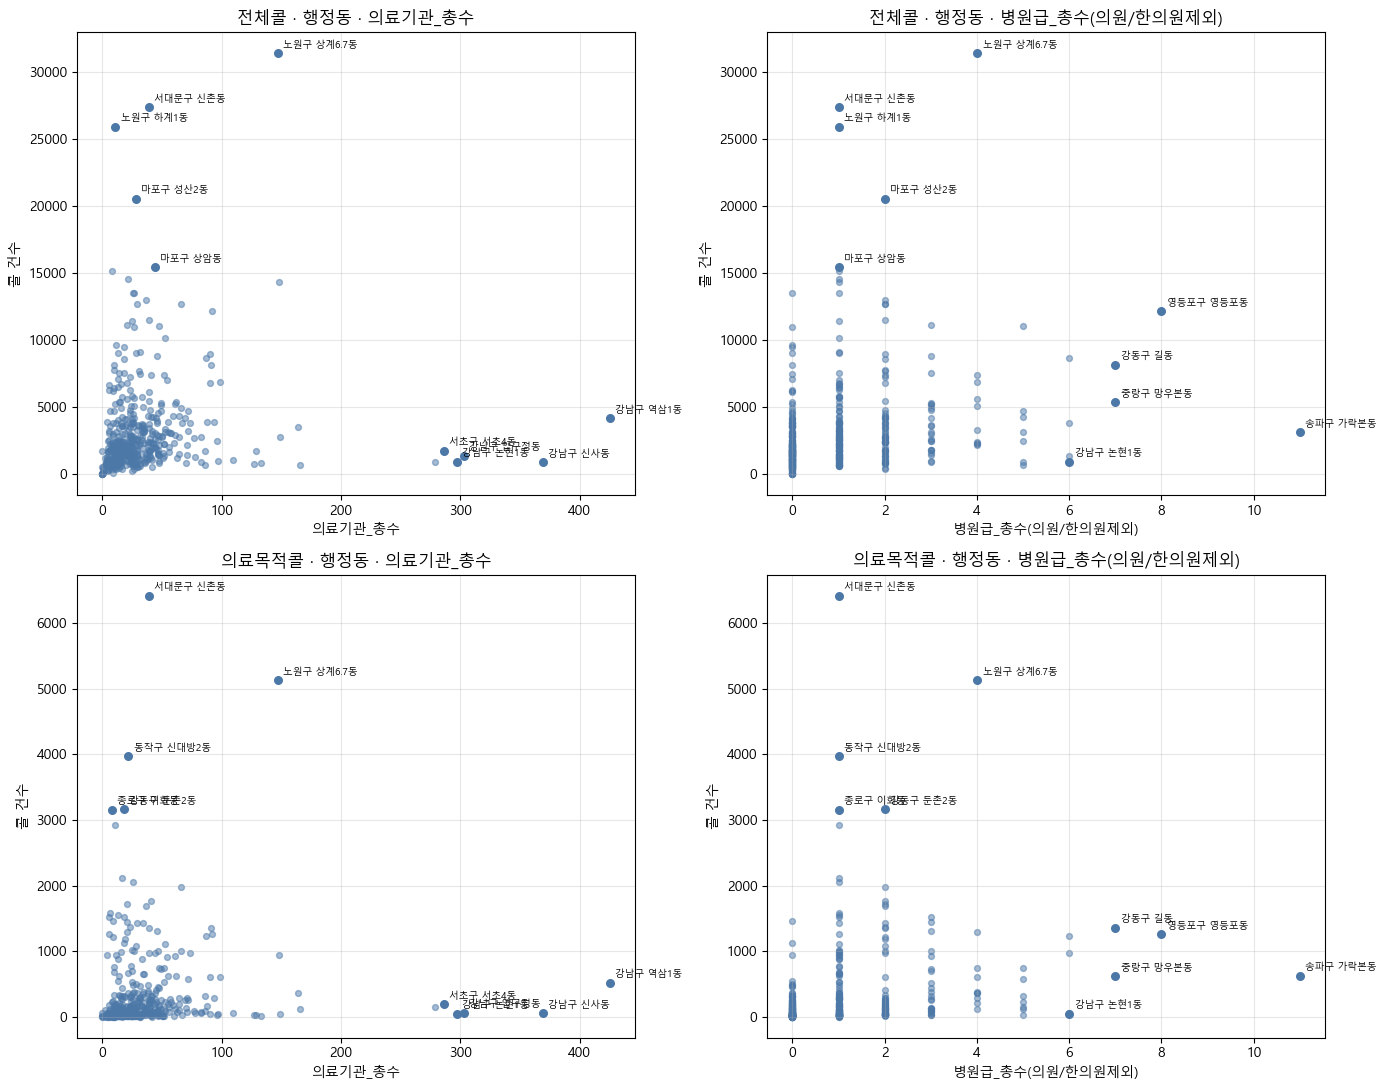

In [3]:
def scatter_metric(df, metric_col, ax, n_label=5):
    ax.scatter(df[metric_col], df["콜건수"], s=18, alpha=0.5, color="#4c78a8")
    id_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    top_x = df.nlargest(n_label, metric_col)
    top_y = df.nlargest(n_label, "콜건수")
    outliers = pd.concat([top_x, top_y]).drop_duplicates(subset=id_cols)
    for _, row in outliers.iterrows():
        label = " ".join(str(row[c]) for c in id_cols)
        ax.annotate(label, (row[metric_col], row["콜건수"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax.scatter(row[metric_col], row["콜건수"], s=30, color="#4c78a8", zorder=3)
    ax.set_xlabel(metric_col)
    ax.set_ylabel("콜 건수")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row_i, call_type in enumerate(["전체콜", "의료목적콜"]):
    df = REGION_CALL[("동", call_type)]
    for col_i, metric in enumerate(["의료기관_총수", "병원급_총수(의원/한의원제외)"]):
        ax = axes[row_i, col_i]
        scatter_metric(df, metric, ax)
        ax.set_title(f"{call_type} · 행정동 · {metric}")
plt.tight_layout()
plt.show()

### 3-2. 산점도: 자치구 단위 (구는 표본이 25개뿐이라 이상치 라벨 없이 전체 점만 표시)

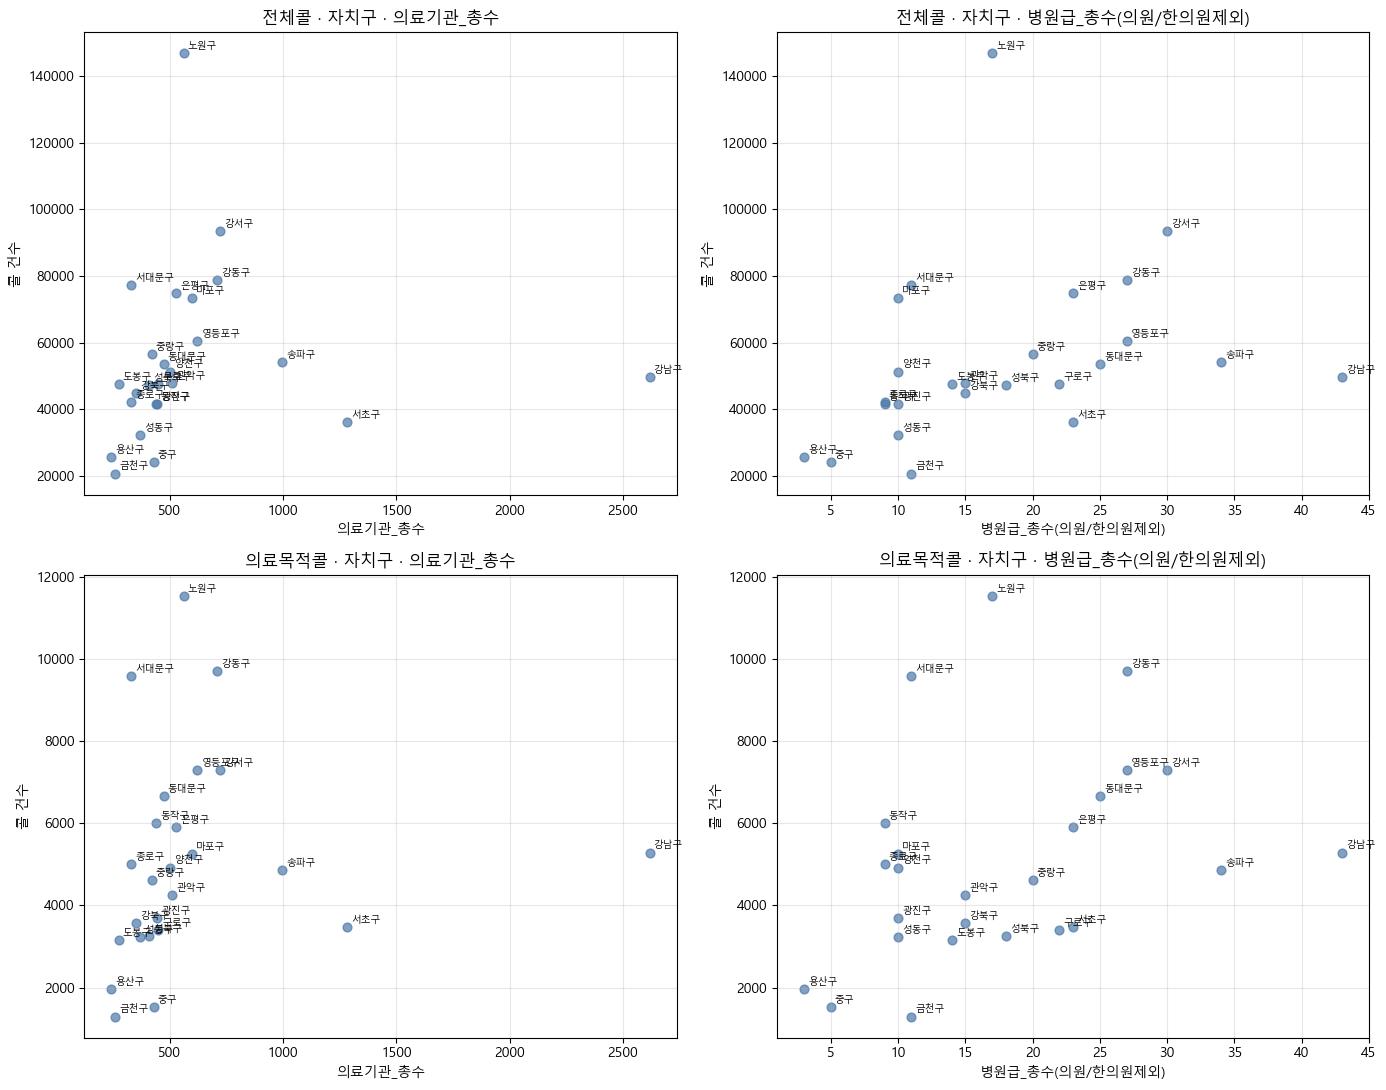

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row_i, call_type in enumerate(["전체콜", "의료목적콜"]):
    df = REGION_CALL[("구", call_type)]
    for col_i, metric in enumerate(["의료기관_총수", "병원급_총수(의원/한의원제외)"]):
        ax = axes[row_i, col_i]
        ax.scatter(df[metric], df["콜건수"], s=40, alpha=0.7, color="#4c78a8")
        for _, row in df.iterrows():
            ax.annotate(row["목적구"], (row[metric], row["콜건수"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(metric)
        ax.set_ylabel("콜 건수")
        ax.set_title(f"{call_type} · 자치구 · {metric}")
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3-3. 상관계수 비교표 — 지역단위 × 콜종류 × 범위(전체/병원급) 전 조합

In [5]:
rows = []
for (region, call_type), df in REGION_CALL.items():
    for metric in ["의료기관_총수", "병원급_총수(의원/한의원제외)"]:
        x, y = df[metric], df["콜건수"]
        pr, pp = stats.pearsonr(x, y)
        sr, sp = stats.spearmanr(x, y)
        rows.append({
            "지역단위": region, "콜종류": call_type, "범위": metric, "n": len(df),
            "Pearson r": round(pr, 3), "Pearson p": f"{pp:.2e}",
            "Spearman rho": round(sr, 3), "Spearman p": f"{sp:.2e}",
        })

corr_wide = pd.DataFrame(rows)
display(corr_wide)

,지역단위,콜종류,범위,n,Pearson r,Pearson p,Spearman rho,Spearman p
0,동,전체콜,의료기관_총수,431,0.093,5.40e-02,0.286,1.54e-09
1,동,전체콜,병원급_총수(의원/한의원제외),431,0.250,1.46e-07,0.354,3.79e-14
2,동,의료목적콜,의료기관_총수,416,0.062,2.04e-01,0.316,4.44e-11
3,동,의료목적콜,병원급_총수(의원/한의원제외),416,0.260,7.37e-08,0.481,1.63e-25
4,구,전체콜,의료기관_총수,25,0.071,7.36e-01,0.520,7.71e-03
5,구,전체콜,병원급_총수(의원/한의원제외),25,0.307,1.35e-01,0.572,2.81e-03
6,구,의료목적콜,의료기관_총수,25,0.124,5.55e-01,0.534,5.99e-03
7,구,의료목적콜,병원급_총수(의원/한의원제외),25,0.345,9.11e-02,0.430,3.17e-02


**구 단위(n=25)는 표본이 작아 p-value 해석에 특히 주의가 필요하다** — 유의하지 않게 나와도 관계가 없다고 단정할 수 없고,
유의하게 나와도 소수 자치구(강남·서초 등) 영향력이 클 수 있다.

#### **결론: "의원·한의원까지 다 합친 숫자보다, 병원급(입원 가능한 규모 이상) 시설 개수만 셌을 때 콜 건수와의 관계가 대체로 더 뚜렷하다" — 즉 콜택시가 의원보다는 병원급 시설과 더 강하게 연결돼 있다는 뜻**

### 3-4. 종별 개별 상관 (의원·한의원 제외 7종) — 지역단위 × 콜종류

[참고] 구 단위 '보건소'는 25개 구 모두 정확히 1개씩이라 분산이 없어 상관계수가 NaN으로 나온다(정상).
--- 동 단위 ---


콜종류,의료목적콜,전체콜
종별,,
병원,0.263,0.159
종합병원,0.410,0.309
요양병원,0.243,0.221
상급종합병원,0.283,0.203
보건소,0.124,0.124
보건지소,-0.023,0.035
정신병원,0.050,0.109


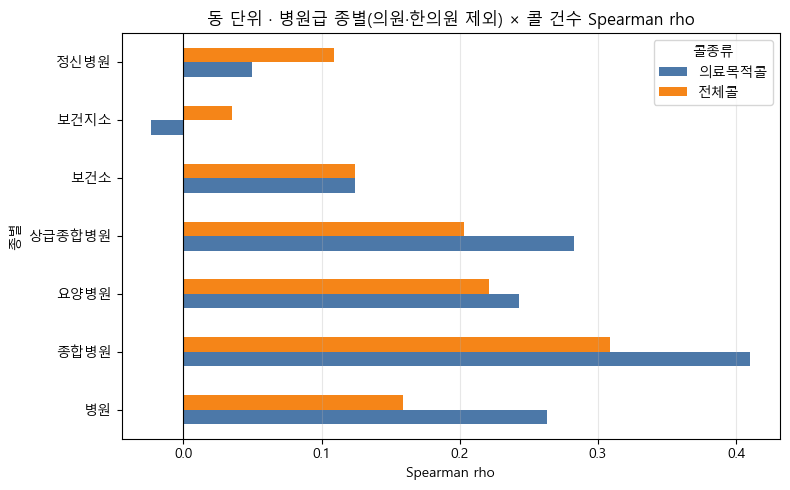

--- 구 단위 ---


콜종류,의료목적콜,전체콜
종별,,
병원,0.342,0.440
종합병원,0.611,0.532
요양병원,0.314,0.510
상급종합병원,0.041,-0.229
보건소,NaN,NaN
보건지소,0.083,0.217
정신병원,-0.022,0.164


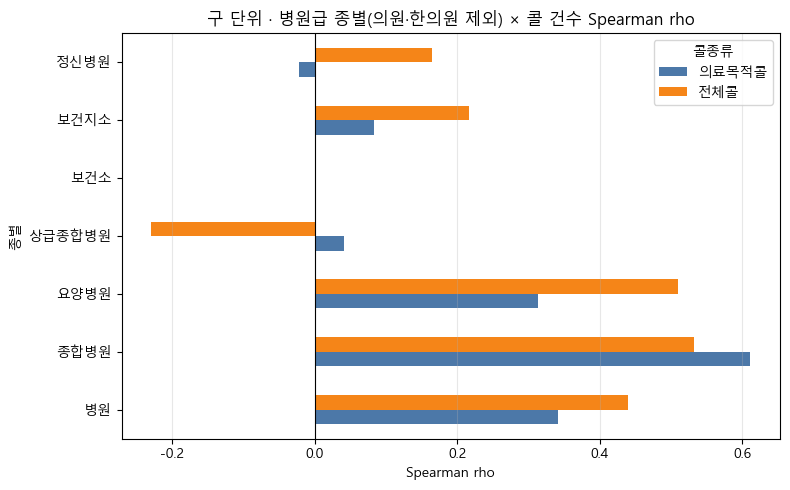

In [6]:
import warnings

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
    for (region, call_type), df in REGION_CALL.items():
        for col in HOSPITAL_GRADE_COLS:
            rho, p = stats.spearmanr(df[col], df["콜건수"])
            rows.append({"지역단위": region, "콜종류": call_type, "종별": col, "n": len(df), "Spearman rho": round(rho, 3), "p": f"{p:.2e}"})

print("[참고] 구 단위 '보건소'는 25개 구 모두 정확히 1개씩이라 분산이 없어 상관계수가 NaN으로 나온다(정상).")

by_type_hospital = pd.DataFrame(rows)

for region in ["동", "구"]:
    sub = by_type_hospital[by_type_hospital["지역단위"] == region]
    pivot = sub.pivot(index="종별", columns="콜종류", values="Spearman rho").loc[HOSPITAL_GRADE_COLS]
    print(f"--- {region} 단위 ---")
    display(pivot)
    pivot.plot(kind="barh", figsize=(8, 5), color=["#4c78a8", "#f58518"])
    plt.title(f"{region} 단위 · 병원급 종별(의원·한의원 제외) × 콜 건수 Spearman rho")
    plt.xlabel("Spearman rho")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

1. 직관적인 현상 해석
의료목적콜 (양의 상관관계, $+$):의미: 상급종합병원이 많은 구일수록 '의료 목적의 이동 콜' 수요는 늘어납니다.

이유: 상급종합병원(대형 3차 병원)은 중증 환자나 먼 지역에서 찾아오는 환자가 많아, 응급차·환자 이송차·의료 특화 택시 등 의료 목적 이송 수요가 해당 지역에 집중되기 때문입니다.

전체콜 (음의 상관관계, $-$):의미: 상급종합병원이 많은 구일수록 '전체 이동 콜(일반 통근·쇼핑·외출 등 포함)' 건수는 오히려 적습니다.

이유: 상급종합병원이 위치한 구는 거주 인구나 일반 상권 중심지라기보다, 대형 의료 인프라나 업무·공공 부지가 크게 자리 잡고 있을 가능성이 높습니다. 따라서 출퇴근이나 일상적 이동 목적의 일반 콜 수요는 상대적으로 적은 지역 특성을 가질 수 있습니다.

2. 데이터 분석 관점에서의 시사점

1) 상급종합병원은 '의료 특화 수요'를 강하게 끌어당김
- 전체적인 이동 수요(전체콜)는 적은 지역이라도, 의료 관련 이동(의료목적콜)만큼은 상급종합병원 유무에 따라 확실히 증가한다는 것을 보여줍니다.

2) 목적별 데이터 분리의 중요성
만약 '전체콜'만 보고 *"상급종합병원이 있는 구는 콜 수요가 적네?"*라고 결론지었다면 오판이 되었을 것입니다.데이터를 '의료목적'으로 세분화(Filtering)했기 때문에 상급종합병원 주변의 실제 의료 이동 특성을 정확히 발굴해낸 좋은 사례.

### 3-5. 보건소 별도 조명

보건소는 공공기관이라 민간 의료기관과 분포 논리가 다르고(구당 원칙적으로 1개 내외), 행정동 단위로는 대부분 0~1개라 희소하다.
그래서 **자치구 단위를 주 해석으로, 행정동 단위는 보조로** 확인한다. 보건지소는 보건소의 하위 조직으로 성격이 달라 섞지 않는다.

In [7]:
print("[구 단위] 보건소 수, 보건지소 수, 콜 건수 (전체콜 기준 정렬)")
health_gu = gu_all[["목적구", "보건소", "보건지소", "콜건수"]].merge(
    gu_med[["목적구", "콜건수"]].rename(columns={"콜건수": "콜건수_의료목적"}), on="목적구"
).sort_values("보건소", ascending=False)
display(health_gu)

print("[참고] 보건소 수는 25개 구 모두 정확히 1이라 분산이 없다 — '보건소 많은 구에 콜이 많다'는 질문 자체가 성립하지 않는 구조다.")
print(f"보건소 수 unique 값: {sorted(gu_all['보건소'].unique().tolist())}")

[구 단위] 보건소 수, 보건지소 수, 콜 건수 (전체콜 기준 정렬)


,목적구,보건소,보건지소,콜건수,콜건수_의료목적
0,강남구,1,0,49717,5287
1,강동구,1,0,78684,9692
2,강북구,1,0,44792,3579
3,강서구,1,0,93425,7295
4,관악구,1,0,47767,4244
5,광진구,1,0,41518,3695
6,구로구,1,1,47455,3393
7,금천구,1,0,20549,1295
8,노원구,1,1,146831,11531
9,도봉구,1,0,47460,3164


[참고] 보건소 수는 25개 구 모두 정확히 1이라 분산이 없다 — '보건소 많은 구에 콜이 많다'는 질문 자체가 성립하지 않는 구조다.
보건소 수 unique 값: [1]


전체콜: 보건소 있음(n=25) 콜건수 중앙값=3194 / 보건소 없음(n=406) 중앙값=2098
의료목적콜: 보건소 있음(n=25) 콜건수 중앙값=176 / 보건소 없음(n=391) 중앙값=73


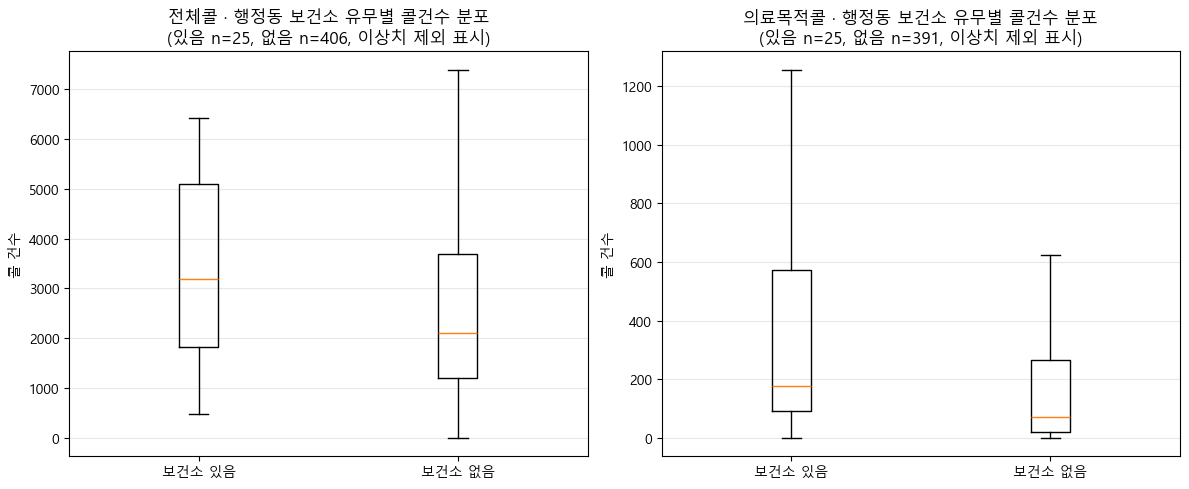


[참고] 행정동 단위는 보건소가 거의 0~1개뿐이라(위 n 참고) 구 단위 해석(3-5 상단)을 우선한다.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (call_type, df) in zip(axes, [("전체콜", dong_all), ("의료목적콜", dong_med)]):
    has_center = np.where(df["보건소"] > 0, "보건소 있음", "보건소 없음")
    groups = [df.loc[has_center == g, "콜건수"] for g in ["보건소 있음", "보건소 없음"]]
    ax.boxplot(groups, tick_labels=["보건소 있음", "보건소 없음"], showfliers=False)
    n_with = (has_center == "보건소 있음").sum()
    n_without = (has_center == "보건소 없음").sum()
    med_with = df.loc[has_center == "보건소 있음", "콜건수"].median()
    med_without = df.loc[has_center == "보건소 없음", "콜건수"].median()
    ax.set_title(f"{call_type} · 행정동 보건소 유무별 콜건수 분포\n(있음 n={n_with}, 없음 n={n_without}, 이상치 제외 표시)")
    ax.set_ylabel("콜 건수")
    ax.grid(axis="y", alpha=0.3)
    print(f"{call_type}: 보건소 있음(n={n_with}) 콜건수 중앙값={med_with:.0f} / 보건소 없음(n={n_without}) 중앙값={med_without:.0f}")
plt.tight_layout()
plt.show()

print("\n[참고] 행정동 단위는 보건소가 거의 0~1개뿐이라(위 n 참고) 구 단위 해석(3-5 상단)을 우선한다.")

[해석] ① 왼쪽 그래프: 전체콜 분포 비교
중앙값 비교: '보건소 있음' 지역의 주황색 선(약 3,200)이 '보건소 없음' 지역(약 2,100)보다 높습니다.

분포 비교: '보건소 있음' 상자의 위치 자체가 전반적으로 위쪽에 놓여 있습니다.

해석: 보건소가 있는 행정동은 보건소가 없는 행정동보다 전체적인 콜 발생량(일상적 이동 포함)이 더 많은 편입니다.

② 오른쪽 그래프: 의료목적콜 분포 비교
중앙값 및 분포 비교: '보건소 있음' 지역의 중앙값(약 180)과 상자 전체 범위가 '보건소 없음' 지역(중앙값 약 70)에 비해 현저하게 위로 치우쳐 있습니다.

최대값(수염) 차이: '보건소 있음' 지역은 최댓값이 1,200건을 넘어서는 반면, '보건소 없음' 지역은 600건 수준에 머뭅니다.

**해석: 보건소가 있는 행정동에서 '의료 목적의 콜 수요'가 확연히 높게 발생합니다.**

## 4. 지역 유형화 — 자치구 단위

07 원본 노트북은 행정동 단위 4분면 유형화만 다뤘다(의료기관_총수·콜건수 중앙값 기준, 전체콜 기준). 같은 로직을 자치구(25개) 단위로도 적용한다.

**분류 기준을 명확히 하면**: 여기서 쓰는 기준값은 **평균(mean)이 아니라 중앙값(median)**이다. 25개 구의 값을 순서대로 세워서 정확히 가운데(13번째)에 오는 값을 기준으로, 그 값 **이상이면 '多'(많음), 미달이면 '少'(적음)**로 나눈다 — 극단적으로 큰 값(강남구 의료기관 2,618개 등)이 평균을 확 끌어올리는 왜곡을 피하려는 목적이다. X축(병원 개수)과 Y축(콜 건수)을 각각 독립적으로 중앙값 기준 二분(binary)한 뒤 그 조합(2×2=4가지)이 A~D형이 된다.

4~4-2에서 쓰는 4가지 기준의 실제 중앙값(자치구 25개 기준)은 다음과 같다:

| 기준 | X축(병원 개수) 중앙값 | Y축(콜 건수) 중앙값 |
|---|---|---|
| 기준1: 의료기관_총수 × 전체콜 | 448개 | 47,767건 |
| 기준2: 병원급_총수(의원/한의원제외) × 의료목적콜 | 15개 | 4,859건 |
| 기준3: 병원급_총수(의원/한의원제외) × 전체콜 | 15개 | 47,767건 |
| 기준4: 의료기관_총수 × 의료목적콜 | 448개 | 4,859건 |

(X축 중앙값은 콜 종류와 무관하게 같다 — 병원 개수는 콜 데이터가 아니라 의료기관 데이터에서 나오기 때문. Y축 중앙값만 전체콜/의료목적콜에 따라 달라진다.)

유형
A (의료多+콜多)    11
D (의료少+콜少)    10
B (의료多+콜少)     2
C (의료少+콜多)     2
Name: count, dtype: int64


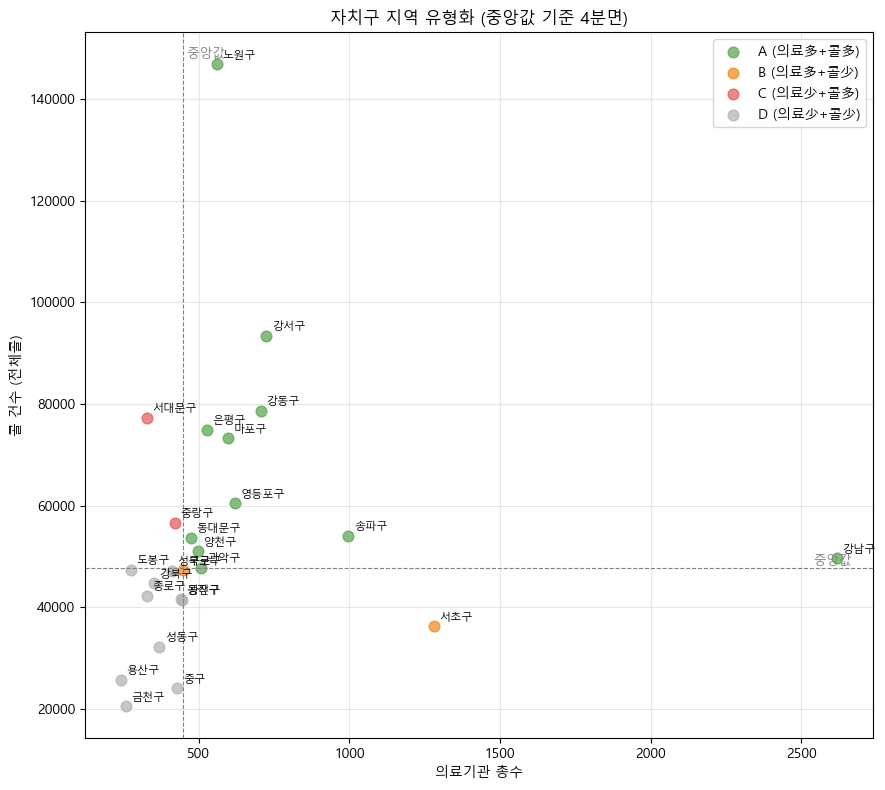

,목적구,유형,콜건수,의료기관_총수,병원급_총수(의원/한의원제외)
8,노원구,A (의료多+콜多),146831,561,17
3,강서구,A (의료多+콜多),93425,724,30
1,강동구,A (의료多+콜多),78684,707,27
13,서대문구,C (의료少+콜多),77346,328,11
21,은평구,A (의료多+콜多),74925,528,23
12,마포구,A (의료多+콜多),73304,596,10
19,영등포구,A (의료多+콜多),60518,622,27
24,중랑구,C (의료少+콜多),56697,420,20
17,송파구,A (의료多+콜多),54062,997,34
10,동대문구,A (의료多+콜多),53680,473,25


In [9]:
gu_q = gu_all.copy()
med_x_gu = gu_q["의료기관_총수"].median()
med_y_gu = gu_q["콜건수"].median()

def classify_gu(row):
    if row["의료기관_총수"] >= med_x_gu and row["콜건수"] >= med_y_gu:
        return "A (의료多+콜多)"
    if row["의료기관_총수"] >= med_x_gu and row["콜건수"] < med_y_gu:
        return "B (의료多+콜少)"
    if row["의료기관_총수"] < med_x_gu and row["콜건수"] >= med_y_gu:
        return "C (의료少+콜多)"
    return "D (의료少+콜少)"

gu_q["유형"] = gu_q.apply(classify_gu, axis=1)
print(gu_q["유형"].value_counts())

colors = {"A (의료多+콜多)": "#54a24b", "B (의료多+콜少)": "#f58518", "C (의료少+콜多)": "#e45756", "D (의료少+콜少)": "#b0b0b0"}
fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q.groupby("유형"):
    ax.scatter(sub["의료기관_총수"], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row["의료기관_총수"], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axvline(med_x_gu, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y_gu, color="gray", linestyle="--", linewidth=0.8)
ax.text(med_x_gu, ax.get_ylim()[1] * 0.98, " 중앙값", color="gray", fontsize=9, va="top", ha="left")
ax.text(ax.get_xlim()[1] * 0.98, med_y_gu, "중앙값 ", color="gray", fontsize=9, va="bottom", ha="right")
ax.set_xlabel("의료기관 총수")
ax.set_ylabel("콜 건수 (전체콜)")
ax.set_title("자치구 지역 유형화 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_q.sort_values("콜건수", ascending=False)[["목적구", "유형", "콜건수", "의료기관_총수", "병원급_총수(의원/한의원제외)"]])

**동 단위(07 원본) vs 구 단위(위) 비교 시 주의**: 동 단위에서 C형(의료少+콜多)으로 분류된 동이 속한 구 자체는
구 단위에서 A형(의료多+콜多)으로 잡힐 수 있다 — 구 전체로는 의료 인프라가 충분해도, 그 안의 특정 동에는 쏠려있지 않을 수 있다는 뜻이라
두 단위 결과가 다르게 나오는 것 자체가 자연스러운 관찰이다.

### 4-1. 비교: 병원급_총수(의원/한의원제외) × 의료목적콜 기준

위와 같은 시각화 설정으로, X축을 `병원급_총수(의원/한의원제외)`(의원·한의원 제외), Y축을 의료목적콜 콜건수로 바꿔서도 자치구를 4분면으로 나눠본다.

유형
A (병원급多+콜多)    8
B (병원급多+콜少)    6
D (병원급少+콜少)    6
C (병원급少+콜多)    5
Name: count, dtype: int64


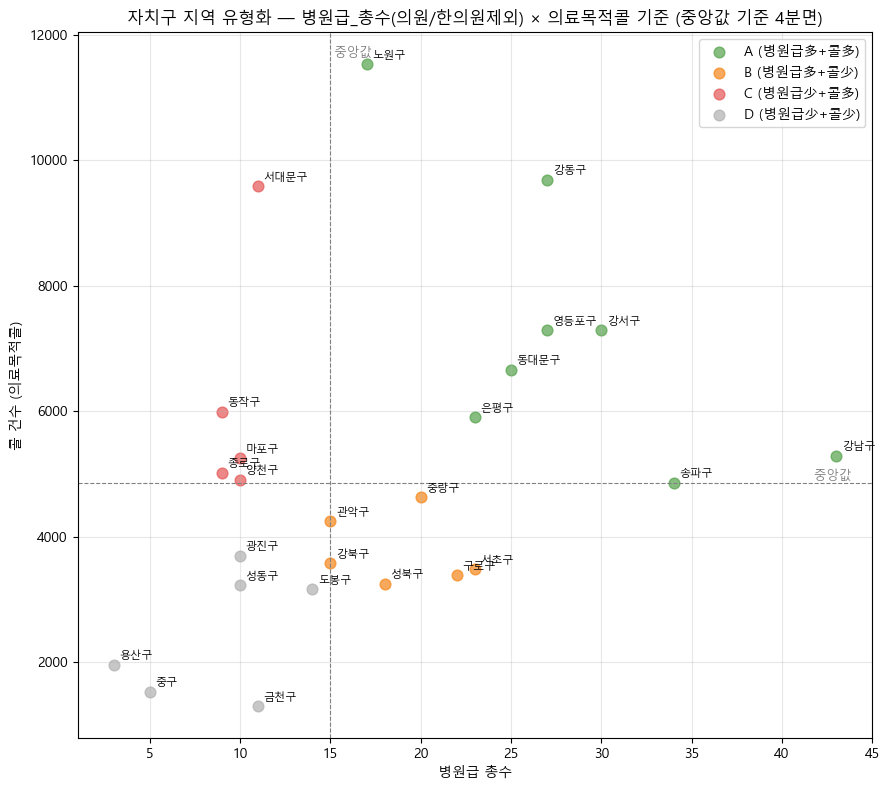

,목적구,유형,콜건수,의료기관_총수,병원급_총수(의원/한의원제외)
8,노원구,A (병원급多+콜多),11531,561,17
1,강동구,A (병원급多+콜多),9692,707,27
13,서대문구,C (병원급少+콜多),9587,328,11
3,강서구,A (병원급多+콜多),7295,724,30
19,영등포구,A (병원급多+콜多),7292,622,27
10,동대문구,A (병원급多+콜多),6664,473,25
11,동작구,C (병원급少+콜多),5994,440,9
21,은평구,A (병원급多+콜多),5902,528,23
0,강남구,A (병원급多+콜多),5287,2618,43
12,마포구,C (병원급少+콜多),5248,596,10


In [10]:
gu_q2 = gu_med.copy()
med_x_gu2 = gu_q2["병원급_총수(의원/한의원제외)"].median()
med_y_gu2 = gu_q2["콜건수"].median()

def classify_gu2(row):
    if row["병원급_총수(의원/한의원제외)"] >= med_x_gu2 and row["콜건수"] >= med_y_gu2:
        return "A (병원급多+콜多)"
    if row["병원급_총수(의원/한의원제외)"] >= med_x_gu2 and row["콜건수"] < med_y_gu2:
        return "B (병원급多+콜少)"
    if row["병원급_총수(의원/한의원제외)"] < med_x_gu2 and row["콜건수"] >= med_y_gu2:
        return "C (병원급少+콜多)"
    return "D (병원급少+콜少)"

gu_q2["유형"] = gu_q2.apply(classify_gu2, axis=1)
print(gu_q2["유형"].value_counts())

colors2 = {"A (병원급多+콜多)": "#54a24b", "B (병원급多+콜少)": "#f58518", "C (병원급少+콜多)": "#e45756", "D (병원급少+콜少)": "#b0b0b0"}
fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q2.groupby("유형"):
    ax.scatter(sub["병원급_총수(의원/한의원제외)"], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors2[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row["병원급_총수(의원/한의원제외)"], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axvline(med_x_gu2, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y_gu2, color="gray", linestyle="--", linewidth=0.8)
ax.text(med_x_gu2, ax.get_ylim()[1] * 0.98, " 중앙값", color="gray", fontsize=9, va="top", ha="left")
ax.text(ax.get_xlim()[1] * 0.98, med_y_gu2, "중앙값 ", color="gray", fontsize=9, va="bottom", ha="right")
ax.set_xlabel("병원급 총수")
ax.set_ylabel("콜 건수 (의료목적콜)")
ax.set_title("자치구 지역 유형화 — 병원급_총수(의원/한의원제외) × 의료목적콜 기준 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_q2.sort_values("콜건수", ascending=False)[["목적구", "유형", "콜건수", "의료기관_총수", "병원급_총수(의원/한의원제외)"]])

### 4-2. 비교

3-2(자치구 산점도 4개를 한 셀에서 비교)와 같은 2x2 레이아웃으로, 자치구 기준 4분면 유형화 네 조합을 한 번에 모아본다 — (의료기관_총수 × 전체콜) · (의료기관_총수 × 의료목적콜) · (병원급_총수(의원/한의원제외) × 전체콜) · (병원급_총수(의원/한의원제외) × 의료목적콜).

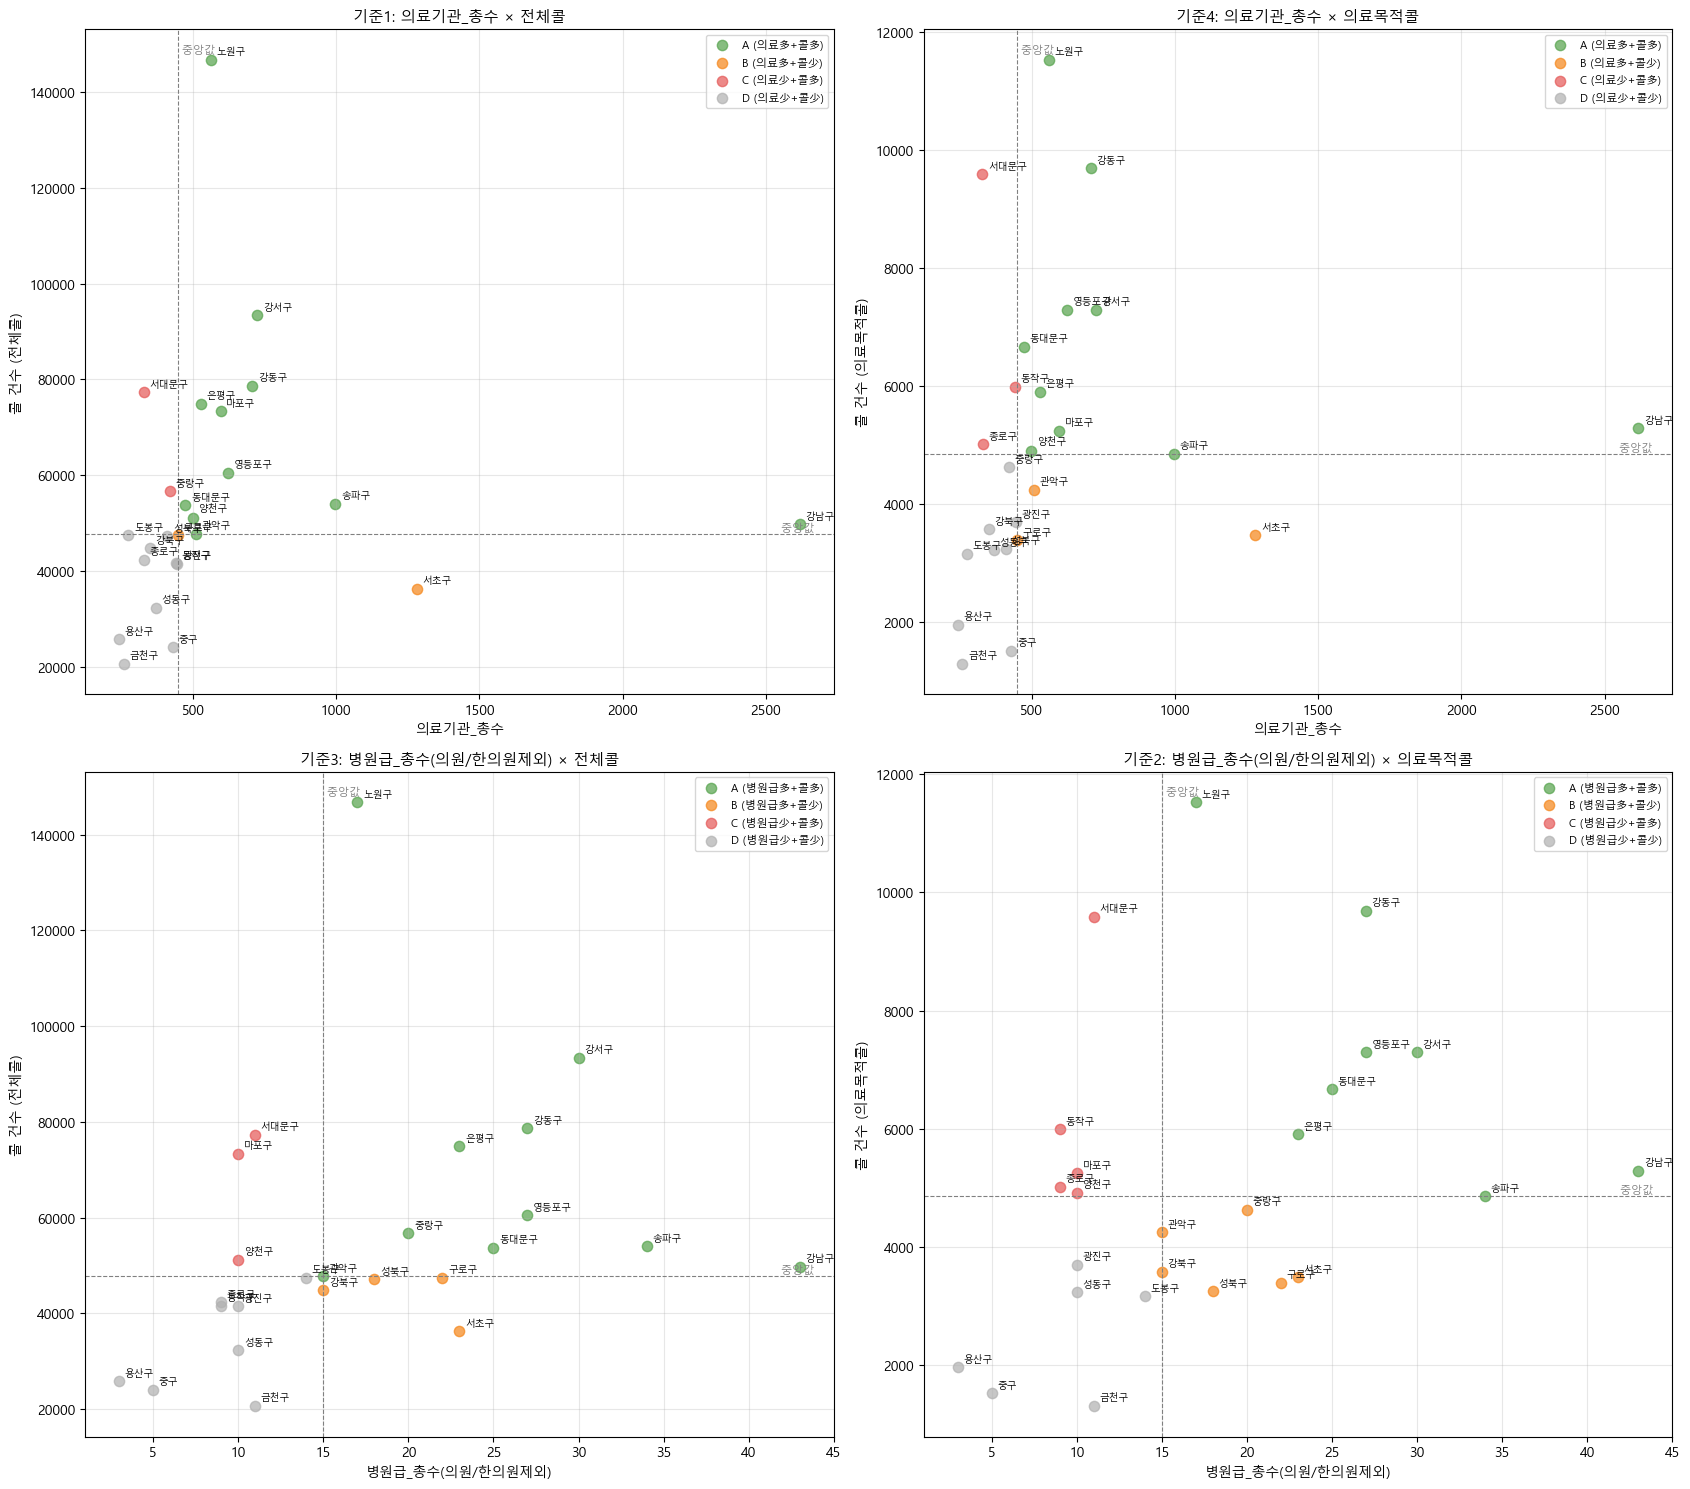

In [11]:
# 이 셀은 4/4-1/4-4에서 쓴 gu_q/gu_q2/gu_q3와 별개로, 실행 순서에 의존하지 않도록 4개 기준을 이 셀 안에서 자체적으로 다시 계산한다.

def build_quadrant(df, xcol, x_short):
    med_x = df[xcol].median()
    med_y = df["콜건수"].median()
    labels = {
        "AA": f"A ({x_short}多+콜多)", "AB": f"B ({x_short}多+콜少)",
        "AC": f"C ({x_short}少+콜多)", "AD": f"D ({x_short}少+콜少)",
    }
    def classify(row):
        if row[xcol] >= med_x and row["콜건수"] >= med_y:
            return labels["AA"]
        if row[xcol] >= med_x and row["콜건수"] < med_y:
            return labels["AB"]
        if row[xcol] < med_x and row["콜건수"] >= med_y:
            return labels["AC"]
        return labels["AD"]
    out = df.copy()
    out["유형"] = out.apply(classify, axis=1)
    cmap = {labels["AA"]: "#54a24b", labels["AB"]: "#f58518", labels["AC"]: "#e45756", labels["AD"]: "#b0b0b0"}
    return out, med_x, med_y, cmap

panels_42 = [
    (*build_quadrant(gu_all, "의료기관_총수", "의료"), "의료기관_총수", "전체콜", "기준1: 의료기관_총수 × 전체콜"),
    (*build_quadrant(gu_med, "의료기관_총수", "의료"), "의료기관_총수", "의료목적콜", "기준4: 의료기관_총수 × 의료목적콜"),
    (*build_quadrant(gu_all, "병원급_총수(의원/한의원제외)", "병원급"), "병원급_총수(의원/한의원제외)", "전체콜", "기준3: 병원급_총수(의원/한의원제외) × 전체콜"),
    (*build_quadrant(gu_med, "병원급_총수(의원/한의원제외)", "병원급"), "병원급_총수(의원/한의원제외)", "의료목적콜", "기준2: 병원급_총수(의원/한의원제외) × 의료목적콜"),
]

fig, axes = plt.subplots(2, 2, figsize=(17, 15))
for ax, (df_q, med_x, med_y, cmap, xcol, call_label, title) in zip(axes.flat, panels_42):
    for label, sub in df_q.groupby("유형"):
        ax.scatter(sub[xcol], sub["콜건수"], s=55, alpha=0.7, label=label, color=cmap[label])
        for _, row in sub.iterrows():
            ax.annotate(row["목적구"], (row[xcol], row["콜건수"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
    ax.text(med_x, ax.get_ylim()[1] * 0.98, " 중앙값", color="gray", fontsize=8, va="top", ha="left")
    ax.text(ax.get_xlim()[1] * 0.98, med_y, "중앙값 ", color="gray", fontsize=8, va="bottom", ha="right")
    ax.set_xlabel(xcol)
    ax.set_ylabel(f"콜 건수 ({call_label})")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4-3. 두 기준 비교표

같은 자치구가 "의료기관_총수 × 전체콜" 기준과 "병원급_총수(의원/한의원제외) × 의료목적콜" 기준에서 다른 유형으로 분류되는지 나란히 비교한다.

In [12]:
compare_type = gu_q[["목적구", "유형"]].rename(columns={"유형": "유형_전체기준(의료기관_총수×전체콜)"}).merge(
    gu_q2[["목적구", "유형"]].rename(columns={"유형": "유형_병원급기준(병원급_총수(의원/한의원제외)×의료목적콜)"}), on="목적구"
)
compare_type["유형_동일여부"] = (
    compare_type["유형_전체기준(의료기관_총수×전체콜)"].str[0] == compare_type["유형_병원급기준(병원급_총수(의원/한의원제외)×의료목적콜)"].str[0]
)
display(compare_type)
print(f"두 기준에서 유형(A/B/C/D)이 같은 구: {compare_type['유형_동일여부'].sum()} / {len(compare_type)}")

,목적구,유형_전체기준(의료기관_총수×전체콜),유형_병원급기준(병원급_총수(의원/한의원제외)×의료목적콜),유형_동일여부
0,강남구,A (의료多+콜多),A (병원급多+콜多),True
1,강동구,A (의료多+콜多),A (병원급多+콜多),True
2,강북구,D (의료少+콜少),B (병원급多+콜少),False
3,강서구,A (의료多+콜多),A (병원급多+콜多),True
4,관악구,A (의료多+콜多),B (병원급多+콜少),False
5,광진구,D (의료少+콜少),D (병원급少+콜少),True
6,구로구,B (의료多+콜少),B (병원급多+콜少),True
7,금천구,D (의료少+콜少),D (병원급少+콜少),True
8,노원구,A (의료多+콜多),A (병원급多+콜多),True
9,도봉구,D (의료少+콜少),D (병원급少+콜少),True


두 기준에서 유형(A/B/C/D)이 같은 구: 17 / 25


### 4-4. 비교: 병원급_총수(의원/한의원제외) × 전체콜 기준

4와 4-1은 각각 (의료기관_총수 × 전체콜), (병원급_총수 × 의료목적콜) 조합만 봤다. 아직 안 본 조합인
**병원급_총수 × 전체콜**을 마저 채운다 — 이래야 "병원급 규모"가 콜 종류(전체 vs 의료목적)에 상관없이
일관되게 나타나는 패턴인지, 아니면 의료목적콜에서만 나타나는 패턴인지 구분할 수 있다.

유형
A (병원급多+콜多)    10
D (병원급少+콜少)     8
B (병원급多+콜少)     4
C (병원급少+콜多)     3
Name: count, dtype: int64


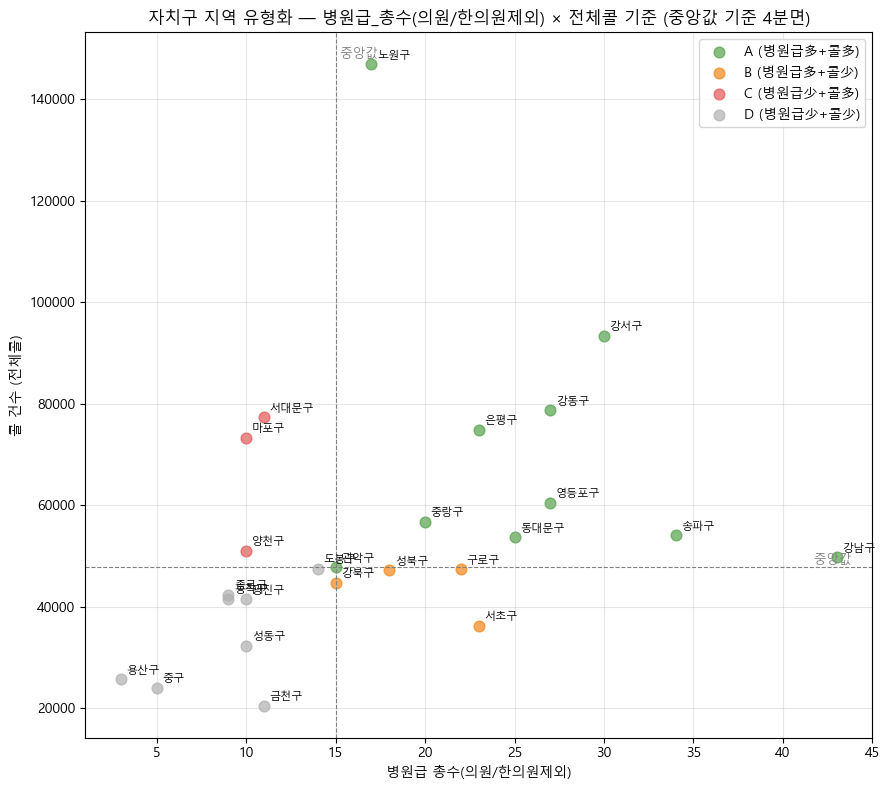

,목적구,유형,콜건수,의료기관_총수,병원급_총수(의원/한의원제외)
8,노원구,A (병원급多+콜多),146831,561,17
3,강서구,A (병원급多+콜多),93425,724,30
1,강동구,A (병원급多+콜多),78684,707,27
13,서대문구,C (병원급少+콜多),77346,328,11
21,은평구,A (병원급多+콜多),74925,528,23
12,마포구,C (병원급少+콜多),73304,596,10
19,영등포구,A (병원급多+콜多),60518,622,27
24,중랑구,A (병원급多+콜多),56697,420,20
17,송파구,A (병원급多+콜多),54062,997,34
10,동대문구,A (병원급多+콜多),53680,473,25


In [13]:
gu_q3 = gu_all.copy()
med_x_gu3 = gu_q3["병원급_총수(의원/한의원제외)"].median()
med_y_gu3 = gu_q3["콜건수"].median()

def classify_gu3(row):
    if row["병원급_총수(의원/한의원제외)"] >= med_x_gu3 and row["콜건수"] >= med_y_gu3:
        return "A (병원급多+콜多)"
    if row["병원급_총수(의원/한의원제외)"] >= med_x_gu3 and row["콜건수"] < med_y_gu3:
        return "B (병원급多+콜少)"
    if row["병원급_총수(의원/한의원제외)"] < med_x_gu3 and row["콜건수"] >= med_y_gu3:
        return "C (병원급少+콜多)"
    return "D (병원급少+콜少)"

gu_q3["유형"] = gu_q3.apply(classify_gu3, axis=1)
print(gu_q3["유형"].value_counts())

fig, ax = plt.subplots(figsize=(9, 8))
for label, sub in gu_q3.groupby("유형"):
    ax.scatter(sub["병원급_총수(의원/한의원제외)"], sub["콜건수"], s=60, alpha=0.7, label=label, color=colors2[label])
    for _, row in sub.iterrows():
        ax.annotate(row["목적구"], (row["병원급_총수(의원/한의원제외)"], row["콜건수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axvline(med_x_gu3, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y_gu3, color="gray", linestyle="--", linewidth=0.8)
ax.text(med_x_gu3, ax.get_ylim()[1] * 0.98, " 중앙값", color="gray", fontsize=9, va="top", ha="left")
ax.text(ax.get_xlim()[1] * 0.98, med_y_gu3, "중앙값 ", color="gray", fontsize=9, va="bottom", ha="right")
ax.set_xlabel("병원급 총수(의원/한의원제외)")
ax.set_ylabel("콜 건수 (전체콜)")
ax.set_title("자치구 지역 유형화 — 병원급_총수(의원/한의원제외) × 전체콜 기준 (중앙값 기준 4분면)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(gu_q3.sort_values("콜건수", ascending=False)[["목적구", "유형", "콜건수", "의료기관_총수", "병원급_총수(의원/한의원제외)"]])

### 4-5. 세 기준 종합 비교표

4(기준1: 의료기관_총수×전체콜), 4-1(기준2: 병원급_총수×의료목적콜), 4-4(기준3: 병원급_총수×전체콜)의 유형을 한 표에 모은다.
**기준2와 기준3은 X축(병원급_총수)이 같고 Y축(콜 종류)만 다르므로, 이 둘이 갈리는 구는 "콜 종류에 따라 결론이 달라지는 구"라는 뜻이다.**

In [14]:
compare_type3 = (
    gu_q[["목적구", "유형"]].rename(columns={"유형": "기준1_의료기관x전체콜"})
    .merge(gu_q2[["목적구", "유형"]].rename(columns={"유형": "기준2_병원급x의료목적콜"}), on="목적구")
    .merge(gu_q3[["목적구", "유형"]].rename(columns={"유형": "기준3_병원급x전체콜"}), on="목적구")
)
compare_type3["기준2·3_일치여부"] = (
    compare_type3["기준2_병원급x의료목적콜"].str[0] == compare_type3["기준3_병원급x전체콜"].str[0]
)
display(compare_type3.sort_values("기준2·3_일치여부"))
print(f"기준2·3(병원급 기준, 콜 종류만 다름)이 같은 구: {compare_type3['기준2·3_일치여부'].sum()} / {len(compare_type3)}")
print(f"기준2·3이 다른 구: {compare_type3.loc[~compare_type3['기준2·3_일치여부'], '목적구'].tolist()}")

,목적구,기준1_의료기관x전체콜,기준2_병원급x의료목적콜,기준3_병원급x전체콜,기준2·3_일치여부
24,중랑구,C (의료少+콜多),B (병원급多+콜少),A (병원급多+콜多),False
22,종로구,D (의료少+콜少),C (병원급少+콜多),D (병원급少+콜少),False
4,관악구,A (의료多+콜多),B (병원급多+콜少),A (병원급多+콜多),False
11,동작구,D (의료少+콜少),C (병원급少+콜多),D (병원급少+콜少),False
21,은평구,A (의료多+콜多),A (병원급多+콜多),A (병원급多+콜多),True
20,용산구,D (의료少+콜少),D (병원급少+콜少),D (병원급少+콜少),True
19,영등포구,A (의료多+콜多),A (병원급多+콜多),A (병원급多+콜多),True
18,양천구,A (의료多+콜多),C (병원급少+콜多),C (병원급少+콜多),True
17,송파구,A (의료多+콜多),A (병원급多+콜多),A (병원급多+콜多),True
16,성북구,D (의료少+콜少),B (병원급多+콜少),B (병원급多+콜少),True


기준2·3(병원급 기준, 콜 종류만 다름)이 같은 구: 21 / 25
기준2·3이 다른 구: ['관악구', '동작구', '종로구', '중랑구']


### 4-6. [관찰] 4~4-5 종합 — 팀 공유용 요약 (수정판)

25개 구를 세 가지 기준(기준1: 의료기관_총수×전체콜 / 기준2: 병원급_총수×의료목적콜 / 기준3: 병원급_총수×전체콜)으로 나눠봤다.

**먼저 정정**: 이전 버전에서는 "강북구·관악구·성북구·중랑구 4개 구가 병원급은 있는데 의료목적 수요로 안 이어진다"고 정리했는데,
이건 기준2(의료목적콜) 하나만 본 결과였다. 기준3(전체콜)까지 같이 보면 4개 구가 서로 다른 이야기를 하고 있었다 — 아래로 정정한다.

**① 콜 종류와 무관하게 일관된 구 (강건한 발견, 20/25개 구)**
기준2와 기준3에서 같은 유형이 나온 구들이다. 즉 "병원급이 많다/적다"와 "콜이 많다/적다"의 관계가 의료목적콜이든 전체콜이든 똑같이 성립한다.
이 중 특히 두 가지가 실무적으로 중요하다.

- **병원급은 부족한데 콜은 많은 구 (C형, 콜 종류 무관하게 일관) → 마포구, 서대문구, 양천구**: 어떤 콜 기준으로 봐도 "병원급 인프라 대비 수요가 크다"는 게 성립한다. 마포구는 섹션 5에서 병상 데이터도 0으로 나온 곳과 일치해 신뢰도가 특히 높다. **의료 인프라 확충 우선순위 후보로 가장 근거가 탄탄한 구들이다.**
- **병원급은 있는데 콜은 적은 구 (B형, 콜 종류 무관하게 일관) → 강북구, 구로구, 서초구, 성북구**: 이 중 구로구·서초구는 애초에 기준1(의료기관_총수)에서도 같은 결과였고, 강북구·성북구는 기준1(D형: 의료기관도 적어보임)에서는 안 보이다가 병원급 기준으로 좁히니 "실제로는 병원급 인프라가 중간 이상은 된다"는 게 드러났다.

**② 콜 종류에 따라 결론이 달라지는 구 (4/25개 구) — 해석에 주의**
기준2(의료목적콜)와 기준3(전체콜)에서 유형이 갈리는 구들이다. "병원급 대비 수요"라는 결론이 어떤 콜을 기준으로 하느냐에 따라 달라진다는 뜻이라, 앞으로 이 구들을 이야기할 때는 반드시 "어떤 콜 기준인지"를 같이 밝혀야 한다.

- **관악구, 중랑구**: 의료목적콜만 보면 "병원급多+콜少"(B)이지만, 전체콜로 보면 "병원급多+콜多"(A)로 바뀐다. 즉 전체 콜 수요 자체는 충분한데, 그중 의료목적 비중이 상대적으로 낮은 구다.
- **동작구, 종로구**: 반대 방향이다. 전체콜만 보면 "병원급少+콜少"(D, 즉 딱히 눈에 띄지 않음)이지만, 의료목적콜로 좁히면 "병원급少+콜多"(C)로 바뀐다. 즉 전체 콜 수요는 두드러지지 않지만, 의료목적콜 비중이 유독 높은 구다.

**결론 — 팀에 공유할 한 문장**: "병원급 인프라가 부족한데 수요가 많다"는 문제는 **마포구·서대문구·양천구가 가장 확실한 사례**이고(어떤 콜 기준으로도 성립), 관악구·동작구·종로구·중랑구는 "전체콜이냐 의료목적콜이냐"에 따라 그림이 달라지니 후속 조사 시 콜 종류를 명시해서 다뤄야 한다.

**주의**: 자치구는 25개뿐이라 표본이 작다. 통계적으로 "확실하다"기보다는 "이런 패턴이 관찰된다" 정도로 보고 참고자료로 활용하는 걸 권장한다.

## 5. 병원 규모 반영 — 중환자실·격리병실 병상수

기존 분석은 전부 "기관 개수"만 세고 있어 규모(병상수)를 반영하지 못한다는 피드백을 반영한다.
`data/raw/건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv`에 병상수(중환자실/격리병실) 데이터가 있어 이를 사용한다.

**한계**: 이 데이터는 전체 의료기관이 아니라 **중환자실·격리병실을 보고한 기관만** 포함한다(전국 765개 중 서울 90개).
의원·보건소·보건지소는 이 데이터에 아예 등장하지 않으므로, "병원급 규모"의 완전한 대체 지표가 아니라
"병원급 시설 중 중증치료 역량이 있는 곳"의 규모를 보여주는 보조 지표로 취급한다.

### 5-1. 데이터 로드 및 결측치 확인

In [15]:
bed_raw = pd.read_csv(RAW_DIR / "건강보험심사평가원_의료기관별 감염병 및 중증환자 치료시설 현황_20260630.csv", encoding="cp949")
bed_seoul = bed_raw[bed_raw["시도명"] == "서울특별시"].copy()

print(f"전국 {len(bed_raw)}행 중 서울 {len(bed_seoul)}행")
print("\n[결측치 확인]")
display(bed_seoul.isnull().sum())
assert bed_seoul.isnull().sum().sum() == 0, "병상 데이터에 결측치가 있다 — 사용 전 처리 필요"
print("[검증 통과] 사용 컬럼 전체 결측치 0건")

print("\n요양기관종별 분포:")
display(bed_seoul["요양기관종별"].value_counts())

bed_seoul["총병상수"] = bed_seoul["중환자실 병상수 소계"] + bed_seoul["격리병실 병상수"]
print(f"\n총병상수 0인 기관 수(보고는 했지만 병상수 0): {(bed_seoul['총병상수'] == 0).sum()} / {len(bed_seoul)}")

전국 765행 중 서울 90행

[결측치 확인]


요양기관명           0
시도명             0
시군구명            0
요양기관종별          0
표시과목            0
주소              0
중환자실 병상수 소계     0
성인 중환자실 병상수     0
소아 중환자실 병상수     0
신생아 중환자실 병상수    0
격리병실 병상수        0
dtype: int64

[검증 통과] 사용 컬럼 전체 결측치 0건

요양기관종별 분포:


요양기관종별
종합병원      40
요양병원      22
상급종합병원    14
병원        13
정신병원       1
Name: count, dtype: int64


총병상수 0인 기관 수(보고는 했지만 병상수 0): 0 / 90


### 5-2. 행정동 매칭 — 기존 05 결과(hospital_info_seoul_행정동_파생컬럼추가.csv)에 기관명+구로 조인

⚠️ **주의**: 이 파일에는 `emdongNm`(기관이 HIRA에 자체 신고한 법정동, 부정확할 수 있음)과
`행정동`(카카오 지오코딩으로 05에서 새로 부여한 행정동, `region_dong_*` 데이터의 행정동과 같은 체계) 두 컬럼이 있다.
**반드시 `행정동` 컬럼을 사용해야 한다** — `emdongNm`으로 조인하면 법정동/행정동 체계가 달라 콜 데이터의 (구,동) 키와
매칭되지 않는 사례가 다수 발생함을 확인했다(예: 상당수 병원의 `emdongNm`이 `dong_all`에 아예 없는 동명으로 나옴).

In [16]:
hosp_ref = pd.read_csv(PROCESSED_DIR / "hospital_info_seoul_행정동_파생컬럼추가.csv", encoding="utf-8-sig")
hosp_ref = hosp_ref[["yadmNm", "sgguCdNm", "행정동"]].drop_duplicates(subset=["yadmNm", "sgguCdNm"])

bed_seoul = bed_seoul.merge(
    hosp_ref, left_on=["요양기관명", "시군구명"], right_on=["yadmNm", "sgguCdNm"], how="left"
)

n_unmatched = bed_seoul["행정동"].isnull().sum()
print(f"행정동 매칭 실패: {n_unmatched} / {len(bed_seoul)}")
if n_unmatched:
    display(bed_seoul[bed_seoul["행정동"].isnull()][["요양기관명", "시군구명", "주소"]])
assert n_unmatched == 0, "행정동 매칭 실패 기관이 있다 — 아래에서 원인 확인 필요"

# [검증] 매칭된 (구,행정동) 키가 dong_all에 실제로 존재하는지 확인 — 존재하지 않으면 저장 시 조용히 유실된다
bed_dong_keys = set(zip(bed_seoul["시군구명"], bed_seoul["행정동"]))
dong_all_keys = set(zip(dong_all["목적구"], dong_all["행정동"]))
missing_keys = bed_dong_keys - dong_all_keys
print(f"dong_all에 없는 (구,행정동) 키 수: {len(missing_keys)}")
assert len(missing_keys) == 0, f"dong_all과 매칭되지 않는 키 존재: {missing_keys}"
print("[검증 통과] 병상 데이터의 모든 (구,행정동) 키가 dong_all에 존재 — 동 단위 집계 시 유실 없음")

# 병원급_총수(의원/한의원제외) 대비 이 데이터의 커버리지 확인 (의원·보건소·보건지소 제외 기준)
covered_types = ["병원", "종합병원", "요양병원", "상급종합병원", "정신병원"]
total_covered_type_count = gu_all[covered_types].sum().sum()
print(f"\n[커버리지] 서울 {covered_types} 총 {total_covered_type_count}개 기관 중, 이 병상 데이터는 {len(bed_seoul)}개 기관만 포함"
      f" ({len(bed_seoul) / total_covered_type_count:.1%})")

행정동 매칭 실패: 0 / 90
dong_all에 없는 (구,행정동) 키 수: 0
[검증 통과] 병상 데이터의 모든 (구,행정동) 키가 dong_all에 존재 — 동 단위 집계 시 유실 없음

[커버리지] 서울 ['병원', '종합병원', '요양병원', '상급종합병원', '정신병원'] 총 405개 기관 중, 이 병상 데이터는 90개 기관만 포함 (22.2%)


### 5-3. 자치구 단위 집계 및 콜건수와의 관계

In [17]:
bed_gu = (
    bed_seoul.groupby("시군구명")
    .agg(병상보고기관수=("요양기관명", "count"), 중환자실병상수=("중환자실 병상수 소계", "sum"), 격리병실병상수=("격리병실 병상수", "sum"))
    .reset_index()
    .rename(columns={"시군구명": "목적구"})
)
bed_gu["총병상수"] = bed_gu["중환자실병상수"] + bed_gu["격리병실병상수"]

# [검증] 구 단위로 집계해도 총병상수 합계가 원본과 같아야 한다 (중복/누락 없음)
assert bed_gu["총병상수"].sum() == bed_seoul["총병상수"].sum(), "구 단위 집계에서 총병상수 합계가 어긋난다"
print(f"[검증 통과] 구 단위 집계 총병상수 합계 = 원본 합계 = {bed_gu['총병상수'].sum():.0f}")

gu_all_bed = gu_all.merge(bed_gu, on="목적구", how="left").fillna(
    {"병상보고기관수": 0, "중환자실병상수": 0, "격리병실병상수": 0, "총병상수": 0}
)
gu_med_bed = gu_med.merge(bed_gu, on="목적구", how="left").fillna(
    {"병상보고기관수": 0, "중환자실병상수": 0, "격리병실병상수": 0, "총병상수": 0}
)
assert len(gu_all_bed) == len(gu_all) and len(gu_med_bed) == len(gu_med), "구 단위 병합 후 행 수가 바뀌었다"
assert gu_all_bed["총병상수"].sum() == bed_gu["총병상수"].sum(), "gu_all 병합 후 총병상수 합계가 어긋난다(25개 구가 bed_gu를 모두 포함하는지 확인 필요)"
print(f"[검증 통과] gu_all_bed 행 수={len(gu_all_bed)}(원본과 동일), 총병상수 합계 보존 확인")

display(gu_all_bed.sort_values("총병상수", ascending=False)[["목적구", "콜건수", "의료기관_총수", "병원급_총수(의원/한의원제외)", "총병상수"]])

for name, df in [("전체콜", gu_all_bed), ("의료목적콜", gu_med_bed)]:
    r, p = stats.spearmanr(df["총병상수"], df["콜건수"])
    print(f"구 단위 총병상수 vs 콜건수({name}) Spearman rho={r:.3f} (p={p:.2e}, n={len(df)})")

[검증 통과] 구 단위 집계 총병상수 합계 = 원본 합계 = 4520
[검증 통과] gu_all_bed 행 수=25(원본과 동일), 총병상수 합계 보존 확인


,목적구,콜건수,의료기관_총수,병원급_총수(의원/한의원제외),총병상수
1,강동구,78684,707,27,509.0
8,노원구,146831,561,17,435.0
0,강남구,49717,2618,43,396.0
17,송파구,54062,997,34,314.0
13,서대문구,77346,328,11,312.0
22,종로구,42322,329,9,271.0
15,성동구,32287,369,10,229.0
19,영등포구,60518,622,27,223.0
11,동작구,41568,440,9,216.0
10,동대문구,53680,473,25,210.0


구 단위 총병상수 vs 콜건수(전체콜) Spearman rho=0.380 (p=6.10e-02, n=25)
구 단위 총병상수 vs 콜건수(의료목적콜) Spearman rho=0.635 (p=6.56e-04, n=25)


### 5-4. 행정동 단위 집계 및 콜건수와의 관계

In [18]:
bed_dong = (
    bed_seoul.groupby(["시군구명", "행정동"])
    .agg(병상보고기관수=("요양기관명", "count"), 중환자실병상수=("중환자실 병상수 소계", "sum"), 격리병실병상수=("격리병실 병상수", "sum"))
    .reset_index()
    .rename(columns={"시군구명": "목적구"})
)
bed_dong["총병상수"] = bed_dong["중환자실병상수"] + bed_dong["격리병실병상수"]
assert bed_dong["총병상수"].sum() == bed_seoul["총병상수"].sum(), "행정동 단위 집계에서 총병상수 합계가 어긋난다"

dong_all_bed = dong_all.merge(bed_dong, on=["목적구", "행정동"], how="left").fillna(
    {"병상보고기관수": 0, "중환자실병상수": 0, "격리병실병상수": 0, "총병상수": 0}
)
dong_med_bed = dong_med.merge(bed_dong, on=["목적구", "행정동"], how="left").fillna(
    {"병상보고기관수": 0, "중환자실병상수": 0, "격리병실병상수": 0, "총병상수": 0}
)
assert len(dong_all_bed) == len(dong_all) and len(dong_med_bed) == len(dong_med), "행정동 단위 병합 후 행 수가 바뀌었다"
assert dong_all_bed["총병상수"].sum() == bed_dong["총병상수"].sum(), "dong_all 병합 후 총병상수 합계가 어긋난다 — 매칭 안 되는 (구,동) 키가 유실됐을 수 있다"
print(f"[검증 통과] dong_all_bed 행 수={len(dong_all_bed)}(원본과 동일), 총병상수 합계 보존 확인 (={dong_all_bed['총병상수'].sum():.0f})")

for name, df in [("전체콜", dong_all_bed), ("의료목적콜", dong_med_bed)]:
    r, p = stats.spearmanr(df["총병상수"], df["콜건수"])
    print(f"행정동 단위 총병상수 vs 콜건수({name}) Spearman rho={r:.3f} (p={p:.2e}, n={len(df)})")

print(f"\n병상 보고 기관이 1개 이상 있는 행정동 수: {(dong_all_bed['총병상수'] > 0).sum()} / {len(dong_all_bed)}")

[검증 통과] dong_all_bed 행 수=431(원본과 동일), 총병상수 합계 보존 확인 (=4520)


행정동 단위 총병상수 vs 콜건수(전체콜) Spearman rho=0.416 (p=1.93e-19, n=431)
행정동 단위 총병상수 vs 콜건수(의료목적콜) Spearman rho=0.498 (p=2.05e-27, n=416)

병상 보고 기관이 1개 이상 있는 행정동 수: 77 / 431


### 5-5. '개수'와 '규모'가 엇갈리는 지역 확인 — 자치구 단위

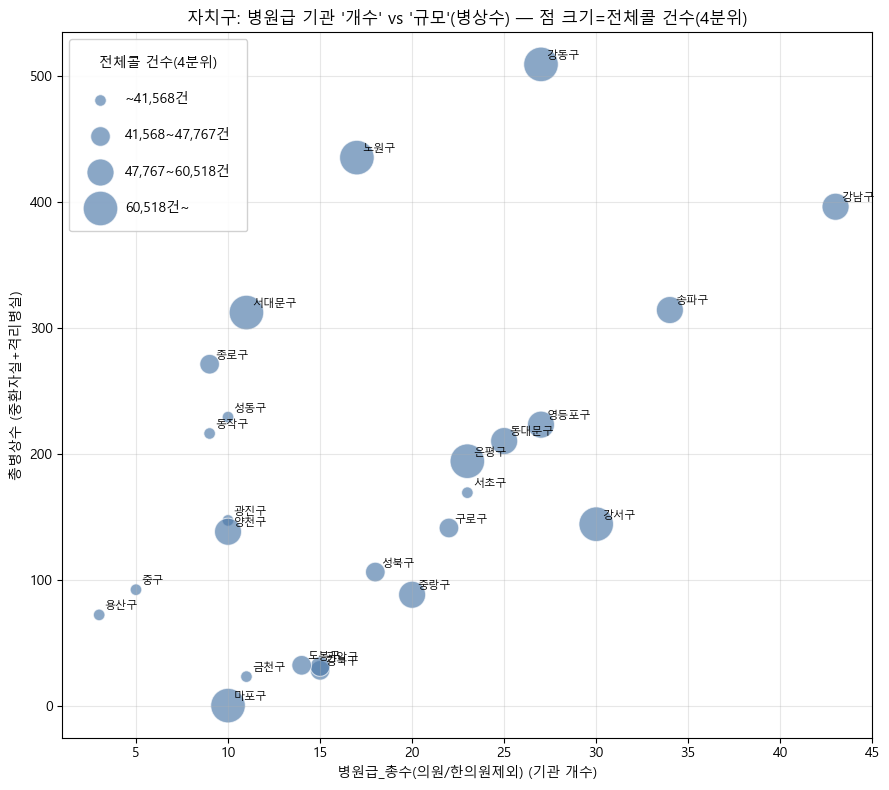

[관찰] 개수 순위와 규모(병상) 순위 차이가 큰 자치구 (기관은 많은데 규모는 작거나, 그 반대)


,목적구,병원급_총수(의원/한의원제외),개수순위,총병상수,규모순위,순위차이
22,종로구,9,22.5,271.0,6.0,16.5
11,동작구,9,22.5,216.0,9.0,13.5
15,성동구,10,19.5,229.0,7.0,12.5
13,서대문구,11,16.5,312.0,5.0,11.5
3,강서구,30,3.0,144.0,14.0,11.0
8,노원구,17,12.0,435.0,2.0,10.0
2,강북구,15,13.5,28.0,23.0,9.5
24,중랑구,20,10.0,88.0,19.0,9.0


In [19]:
# 콜건수가 오른쪽으로 치우쳐 있어(노원구 1개가 나머지를 압도) 값에 선형비례한 점 크기는
# 대부분의 점이 서로 거의 구분 안 되는 크기로 뭉친다. 4분위 구간으로 나눠 크기를 명확히 벌리고,
# 범례에 실제 콜건수 구간을 표시한다.
call_col = gu_all_bed["콜건수"]
size_order = ["1분위(적음)", "2분위", "3분위", "4분위(많음)"]
size_map = {"1분위(적음)": 70, "2분위": 200, "3분위": 380, "4분위(많음)": 620}
size_bins = pd.qcut(call_col, 4, labels=size_order)
sizes = size_bins.map(size_map)

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    gu_all_bed["병원급_총수(의원/한의원제외)"], gu_all_bed["총병상수"],
    s=sizes, alpha=0.65, color="#4c78a8", edgecolors="white", linewidth=0.8,
)
for _, row in gu_all_bed.iterrows():
    ax.annotate(row["목적구"], (row["병원급_총수(의원/한의원제외)"], row["총병상수"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("병원급_총수(의원/한의원제외) (기관 개수)")
ax.set_ylabel("총병상수 (중환자실+격리병실)")
ax.set_title("자치구: 병원급 기관 '개수' vs '규모'(병상수) — 점 크기=전체콜 건수(4분위)")
ax.grid(alpha=0.3)

qs = call_col.quantile([0, 0.25, 0.5, 0.75, 1]).astype(int)
legend_labels = [
    f"~{qs.iloc[1]:,}건", f"{qs.iloc[1]:,}~{qs.iloc[2]:,}건",
    f"{qs.iloc[2]:,}~{qs.iloc[3]:,}건", f"{qs.iloc[3]:,}건~",
]
legend_handles = [
    ax.scatter([], [], s=size_map[label], color="#4c78a8", alpha=0.65, edgecolors="white", linewidth=0.8)
    for label in size_order
]
ax.legend(legend_handles, legend_labels, title="전체콜 건수(4분위)", loc="upper left", labelspacing=1.6, borderpad=1.2, framealpha=0.9)

plt.tight_layout()
plt.show()

# 순위 컬럼은 이 관찰용으로만 쓰는 임시본이라 gu_all_bed 자체에는 추가하지 않는다(저장 파일 스키마를 gu_med_bed와 동일하게 유지하기 위함)
gu_rank_check = gu_all_bed.copy()
gu_rank_check["개수순위"] = gu_rank_check["병원급_총수(의원/한의원제외)"].rank(ascending=False)
gu_rank_check["규모순위"] = gu_rank_check["총병상수"].rank(ascending=False)
gu_rank_check["순위차이"] = (gu_rank_check["개수순위"] - gu_rank_check["규모순위"]).abs()
print("[관찰] 개수 순위와 규모(병상) 순위 차이가 큰 자치구 (기관은 많은데 규모는 작거나, 그 반대)")
display(
    gu_rank_check.sort_values("순위차이", ascending=False)
    .head(8)[["목적구", "병원급_총수(의원/한의원제외)", "개수순위", "총병상수", "규모순위", "순위차이"]]
)

# 눈에 띄는 사례

### 강동구 vs 강서구 — 개수는 비슷한데 규모는 3.5배 차이
둘 다 병원급 27~30개로 비슷한데, 병상수는 강동구 509개, 강서구 144개입니다. "기관 수는 비슷해도 강동구엔 큰 병원이, 강서구엔 상대적으로 작은 병원이 많다"는 뜻입니다.

### 노원구 — 개수는 적은데 규모는 2위
병원급 17개뿐인데 병상수는 435개(전체 2위)입니다. 소수의 대형병원이 규모를 끌어올린 경우입니다.

### 강남구 — 개수·규모 둘 다 최상위권
병원급 43개(1위)에 병상수도 396개(3위)로, 양쪽 다 크게 자리 잡고 있습니다.

### 마포구 — 병원급 10개인데 병상수 0 (원인 확인됨: 샘플링 문제 아님)
차트 맨 아래, 그것도 꽤 큰 점(콜 건수는 상위권)인데 Y값이 0입니다. 처음엔 "병상 데이터가 서울 병원급 기관의 22%만 커버하는 부분 데이터라 마포구가 우연히 빠졌을 가능성"도 의심했으나, 원자료(`hospital_info_seoul_행정동_파생컬럼추가.csv`)를 직접 확인해 **샘플링 문제가 아니라는 걸 확인**했다.

- 마포구의 병원급 10개(의원·한의원 제외) 구성: 병원 6개, 요양병원 3개, 보건소 1개 — **종합병원·상급종합병원·정신병원이 단 한 곳도 없다.**
- 이 9개 병원 중 의사 수(`drTotCnt`)가 가장 많은 곳도 신촌연세병원(16명)뿐이고, 나머지는 2~8명 수준의 소규모 병원이다. 참고로 상급종합병원(서울대병원 등)은 보통 수백~1,500명대다.
- 이 병상 데이터(전국 765개, 서울 90개)에도 마포구는 **전국 기준으로 0건**이다 — 22% 샘플에서 우연히 빠진 게 아니라, 애초에 마포구에 이 조사 대상이 될 만한 대형병원이 없다.

**결론**: 마포구는 실제로 중환자실·격리병실급 대형병원이 없는 구다(위 두 가설 중 ①). 마포구의 "병원급_총수 10개"는 전부 소규모 병원·요양병원·보건소이고, 콜 목적지 수요는 많은데(상위권) 이를 받아줄 대형 의료 인프라는 없다는 뜻이라 — 4-6 섹션에서 "인프라 확충 우선순위 후보"로 꼽은 것과 정확히 같은 방향의 근거다.

### 점 크기(콜 건수) 기준으로 봐도 패턴이 없음
콜이 가장 많은 축에 속하는 강서구·강동구·서대문구·은평구·마포구 같은 구들이 Y값(규모)에서는 509부터 0까지 완전히 흩어져 있습니다. "콜이 많다고 병상 규모도 크다"는 보장이 없다는 뜻입니다.

## 6. 데이터 검증 및 결과 CSV 저장

섹션 1·5에서 계산 단계마다 이미 검증했지만(파생컬럼 합산 일치, 결측치 0건, 행정동 매칭 100%, 키 유실 없음, 병합 전후 합계 보존),
저장 직전에 최종 4개 결과 데이터프레임(`dong_all_bed`, `dong_med_bed`, `gu_all_bed`, `gu_med_bed`)에 대해 한 번 더 종합 검증한다.

In [20]:
FINAL = {
    "dong_all_bed": dong_all_bed, "dong_med_bed": dong_med_bed,
    "gu_all_bed": gu_all_bed, "gu_med_bed": gu_med_bed,
}
ORIGINAL = {"dong_all_bed": dong_all, "dong_med_bed": dong_med, "gu_all_bed": gu_all, "gu_med_bed": gu_med}

checks = []
for name, df in FINAL.items():
    orig = ORIGINAL[name]
    row_ok = len(df) == len(orig)
    call_sum_ok = df["콜건수"].sum() == orig["콜건수"].sum()
    key_cols = ["목적구", "행정동"] if "행정동" in df.columns else ["목적구"]
    dup_ok = not df.duplicated(subset=key_cols).any()
    null_cols = ["병원급_총수(의원/한의원제외)", "병상보고기관수", "중환자실병상수", "격리병실병상수", "총병상수"]
    null_ok = df[null_cols].isnull().sum().sum() == 0
    checks.append({
        "데이터셋": name, "행 수 보존": row_ok, "콜건수 합계 보존": call_sum_ok,
        "키 중복 없음": dup_ok, "결측치 없음": null_ok,
    })

check_df = pd.DataFrame(checks)
display(check_df)
assert check_df.drop(columns="데이터셋").all(axis=None), "검증 실패 항목이 있다 — 저장 중단"
print("[검증 통과] 4개 데이터셋 모두 행 수 보존·콜건수 합계 보존·키 중복 없음·결측치 없음 확인")

# 전체콜/의료목적콜 짝(dong_all_bed↔dong_med_bed, gu_all_bed↔gu_med_bed)의 컬럼 구성이 동일한지 확인
assert list(dong_all_bed.columns) == list(dong_med_bed.columns), "dong_all_bed와 dong_med_bed의 컬럼 구성이 다르다"
assert list(gu_all_bed.columns) == list(gu_med_bed.columns), "gu_all_bed와 gu_med_bed의 컬럼 구성이 다르다"
print("[검증 통과] 전체콜/의료목적콜 짝끼리 컬럼 구성 동일 (dong 20열, gu 19열)")

,데이터셋,행 수 보존,콜건수 합계 보존,키 중복 없음,결측치 없음
0,dong_all_bed,True,True,True,True
1,dong_med_bed,True,True,True,True
2,gu_all_bed,True,True,True,True
3,gu_med_bed,True,True,True,True


[검증 통과] 4개 데이터셋 모두 행 수 보존·콜건수 합계 보존·키 중복 없음·결측치 없음 확인
[검증 통과] 전체콜/의료목적콜 짝끼리 컬럼 구성 동일 (dong 20열, gu 19열)


In [21]:
SAVE_SPECS = {
    "dong_all_bed": ("region_dong_call_hospital_combined_병원급규모추가.csv", ORIGINAL_CALL_COL["dong_all"]),
    "dong_med_bed": ("region_dong_call_hospital_combined_medical_병원급규모추가.csv", ORIGINAL_CALL_COL["dong_med"]),
    "gu_all_bed": ("region_gu_call_hospital_combined_병원급규모추가.csv", ORIGINAL_CALL_COL["gu_all"]),
    "gu_med_bed": ("region_gu_call_hospital_combined_medical_병원급규모추가.csv", ORIGINAL_CALL_COL["gu_med"]),
}

for name, (filename, call_col) in SAVE_SPECS.items():
    df = FINAL[name].rename(columns={"콜건수": call_col})
    out_path = PROCESSED_DIR / filename
    df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장 완료: {out_path} ({df.shape[0]}행 x {df.shape[1]}열)")

print("\n[신규 컬럼] 기존 원본 컬럼 + 병원급_총수(의원/한의원제외), 병상보고기관수, 중환자실병상수, 격리병실병상수, 총병상수")

저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_병원급규모추가.csv (431행 x 20열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_dong_call_hospital_combined_medical_병원급규모추가.csv (416행 x 20열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_병원급규모추가.csv (25행 x 19열)
저장 완료: C:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_gu_call_hospital_combined_medical_병원급규모추가.csv (25행 x 19열)

[신규 컬럼] 기존 원본 컬럼 + 병원급_총수(의원/한의원제외), 병상보고기관수, 중환자실병상수, 격리병실병상수, 총병상수


## 7. 종합 인사이트 정리 (섹션 1~6 전체)

**[확인된 사실]**
- 07 원본과 동일하게, 구·동 단위 의료기관 총수와 콜 건수의 Pearson 상관은 약하고(전체콜 r=0.093 / 의료목적콜 r=0.062), Spearman 순위상관은 뚜렷하다(0.286 / 0.316).
- **의원·한의원을 제외한 `병원급_총수(의원/한의원제외)`는 `의료기관_총수`보다 대체로 콜 건수와 더 강하게 연관된다**: 동 단위 Spearman이 전체콜 0.286→0.354, 의료목적콜 0.316→0.481로 뚜렷이 상승했고, 구 단위도 전체콜 0.520→0.572로 상승했다. 다만 구 단위 의료목적콜만 0.534→0.430으로 소폭 하락했는데, 구 단위는 n=25로 표본이 작아 이 하락을 과도하게 해석하지 않는다. 07에서 세운 "병원급이 더 강한 관계일 것"이라는 가설이 대체로 지지된다.
- 종별 중에서는 동·구 단위 모두 **종합병원**이 콜 건수와 가장 강하게 연관된다(동: 0.309/0.410, 구: 0.532/0.611) — 두 지역 단위에서 일관되게 나타나는 결과.
- **상급종합병원은 동 단위(양의 상관 0.203~0.283)와 구 단위(전체콜 -0.229, 의료목적콜 0.041)에서 방향이 어긋난다.** 상급종합병원이 몰려 있는 강남·서초구 자체가 콜 수요는 낮은 지역이기 때문으로 보인다 — 개별 동 단위 관찰과 구 전체 집계 결과가 다를 수 있다는 사례.
- **보건소는 25개 구 전부에 정확히 1개씩, 25개 동에만 위치**해 구 단위로는 분산이 없어 상관계수 자체가 정의되지 않는다(구조적으로 "보건소 많은 구에 콜이 많다"는 질문이 성립하지 않음). 다만 보건소가 있는 동의 콜건수 중앙값은 없는 동보다 높다(전체콜 3,194 vs 2,098 / 의료목적콜 176 vs 73) — 보건소가 대개 구청 소재지 등 중심지에 위치하는 데서 오는 부수적 패턴일 가능성이 있다.
- 병상 규모(중환자실+격리병실) 데이터는 서울 병원급 대형기관(병원·종합병원·요양병원·상급종합병원·정신병원, 405개) 중 **90개(22.2%)만 커버**한다. 의원·보건소·보건지소는 이 데이터에 아예 없다. 결측치는 0건(사용한 11개 컬럼 전부).
- **구 단위 총병상수-콜건수 상관은 의료목적콜에서 훨씬 강하다**(rho=0.635, p<0.001 vs 전체콜 rho=0.380, p=0.061, 경계) — "이용목적을 의료로 좁힐수록 의료기관 관련 관계가 더 선명해진다"는 07의 관찰이 병상 규모 지표에서도 동일한 방향으로 재현된다.
- **동 단위 총병상수-콜건수 상관도 강하고 매우 유의하다**(전체콜 rho=0.416, p=1.9e-19 / 의료목적콜 rho=0.498, p=2.1e-27, n=431/416, 병상 데이터가 있는 동은 77개). 이 수치는 검증 과정에서 한 번 바로잡은 결과다 — 처음에는 병상 데이터를 `hospital_info_seoul_행정동_파생컬럼추가.csv`의 `emdongNm`(기관이 자체 신고한 법정동) 컬럼으로 조인했더니 431개 동 중 18개에만 매칭돼 상관이 약하게(rho 0.18~0.24) 나왔는데, 카카오 지오코딩 기반 `행정동` 컬럼으로 바로잡자 매칭된 동이 77개로 늘고 상관도 뚜렷하게 강해졌다. **법정동과 행정동을 혼동하면 안 된다는 걸 보여주는 사례라 기록해둔다.**

**[탐색적 관계]**
- 병원급 기관 '개수' 순위와 '병상 규모' 순위 차이가 큰 구들이 있다: 종로구·동작구·성동구·서대문구는 기관 개수는 적지만 병상 규모 순위는 훨씬 높다(대형병원 소수 집중형). 강서구·노원구·강북구·중랑구는 반대로 개수는 많지만 병상 규모는 하위권이다(소형기관 다수·분산형).
- **마포구**는 콜 목적지 건수가 73,304건(구 단위 상위권)이면서도 병원급_총수(의원/한의원제외)는 10개(하위권)이고, 병상 데이터에 매칭되는 기관이 0개다 — 섹션4의 "의료기관_총수" 기준으로는 A형(의료多+콜多)에 속하지만, 이는 의원 수(전체 의료기관_총수 596개 중 병원급은 10개뿐)에 좌우된 분류이고 병원급·병상 규모로 보면 다른 그림이 된다.
- 구 단위 4분면 유형화(섹션4)에서 서대문구·중랑구가 C형(의료少+콜多)으로 나타난다 — 07 원본의 동 단위 결과에서도 두 구에 속한 일부 동(홍은2동 등)이 C형으로 분류됐던 것과 방향이 일치해, 구 전체 수준에서도 같은 패턴이 재현된다.
- 노원구는 구 단위로는 A형(의료多+콜多)이지만, 07 원본에서 내부 동 단위로 보면 하계1동·월계2동처럼 C형(의료少+콜多)인 동이 섞여 있었다 — 구 전체 지표만 보면 내부의 불균등한 분포를 놓칠 수 있다는 근거다.

**[가설]**
- 종합병원·상급종합병원처럼 병원급 이상 의료기관이 콜 목적지 패턴과 더 밀접하게 연관될 수 있다는 07의 가설은, 이번 병원급_총수(의원/한의원제외) 분석과 병상 규모 분석 모두에서 "의료목적콜로 좁힐수록 관계가 강해진다"는 같은 방향의 근거가 추가로 확인되어 다소 힘을 얻는다(교차검증).
- 병상 규모(중증치료 역량)가 콜 목적지 수요의 대리지표가 될 수 있다는 가설을 세울 수 있으나, 커버리지 22%인 부분 데이터 기반이라 확정적이지 않다.
- 마포구·강서구·노원구·중랑구처럼 '개수는 많지만 병상 규모는 작은' 구는 의료 자원이 소형·분산돼 있어, 중증 의료 목적 콜에 대한 실제 대응 역량이 겉보기(기관 개수)보다 낮을 수 있다는 가설을 세울 수 있다. 배차·우선순위 정책 검토 시 참고할 만하나, 대기시간 등 다른 지표와 함께 검증이 필요하다.

**[인과관계 — 주장하지 않음]**
- "병상이 많아서/적어서 콜 수요가 늘거나 준다"거나 "의료기관이 많아서 콜 이용량이 늘었다"는 주장은 하지 않는다.
- 인구·면적을 보정하지 않았고, 병상 데이터는 전체 병원급 기관의 22%만 커버하는 표본이므로, 관찰된 상관관계가 동/구 규모나 데이터 커버리지 편향에서 비롯됐을 가능성을 배제할 수 없다.

## 한계 및 추가 분석 방향 (갱신)

- **인구·면적 미보정**: 07과 동일한 핵심 한계. 향후 인구 대비 정규화가 필요하다.
- **Pearson vs Spearman 괴리**: 07과 동일하게 관찰됨 — 로그 변환 등으로 분포를 조정한 뒤 재확인할 필요가 있다.
- **동 단위 매칭 잔여**: 서빙고동(0건 확인)과 "중구" 4개 동(도원동·동인천동·북성동·연안동)은 실제로는 존재하지 않는 구·동 조합이다. 도원동은 용산구 소속인데 중구로 잘못 붙었고, 동인천동·북성동·연안동은 서울이 아니라 인천 중구의 동명이다 — 콜 목적지 라벨링 단계에서 "중구"라는 구 이름이 서울·인천에 모두 존재해 생긴 것으로 추정된다. 27건/136만 건(0.002%)뿐이라 이번 통계 분석에는 영향이 없지만, **향후 지도 기반 서비스에서는 좌표가 실제로 잘못된 위치에 찍히는 문제로 이어지므로, 지도 서비스 착수 전 콜 목적지 라벨링 단계에서 시도(서울/인천) 구분을 넣어 재작업이 필요하다.**
- **병상 규모 데이터의 제한적 커버리지**: 서울 병원급 대형기관 405개 중 90개(22.2%)만 포함하며, 의원·보건소·보건지소는 아예 없다. 전수 병상수를 확보할 수 있다면(예: HIRA 병원정보서비스 상세 API) 재검증이 필요하다.
- **법정동/행정동 컬럼 혼동 주의**: `hospital_info_seoul_행정동_파생컬럼추가.csv`에는 `emdongNm`(법정동, 기관 자체신고)과 `행정동`(카카오 지오코딩) 두 컬럼이 있다. 이번 작업에서 처음에 `emdongNm`으로 조인했다가 매칭률이 크게 떨어지는 문제를 발견해 `행정동`으로 바로잡았다 — 이 파일을 다른 분석에서 재사용할 때도 반드시 `행정동` 컬럼을 써야 한다.
- **보건소 분석의 구조적 한계**: 보건소는 배치 원칙(구당 1개) 자체가 콜 수요와 무관하므로, "보건소 개수"보다는 "보건소까지의 접근성/거리" 같은 지표로 접근하는 것이 더 유의미할 수 있다.
- **진료과목 분석 불가**: 07과 동일 — 재활의학과 등 세부 진료과목은 현재 HIRA 데이터로 확인할 수 없다.
- **다음 분석 제안**: (1) 인구 대비 정규화, (2) 전수 병상수 확보 후 재검증, (3) 대기시간·배차시간과 병원급/병상 규모의 관계, (4) 마포구·노원구 등 '개수-규모 불일치' 구의 상세 사례 분석, (5) 콜 목적지 라벨링의 시도 구분 정비(지도 서비스 선행 과제).

## 저장된 결과 파일

섹션 6에서 검증을 통과한 4개 데이터셋을 `data/processed/`에 저장했다 (원본 CSV는 그대로 두고 새 파일로 저장 — 기존 파일 수정 없음):

- `region_dong_call_hospital_combined_병원급규모추가.csv` (431행 × 20열)
- `region_dong_call_hospital_combined_medical_병원급규모추가.csv` (416행 × 20열)
- `region_gu_call_hospital_combined_병원급규모추가.csv` (25행 × 19열)
- `region_gu_call_hospital_combined_medical_병원급규모추가.csv` (25행 × 19열)

기존 컬럼 + `병원급_총수(의원/한의원제외)`, `병상보고기관수`, `중환자실병상수`, `격리병실병상수`, `총병상수` 5개 신규 컬럼을 포함한다.